In [1]:
# CELL 1 — IMPORTS, PATHS & GLOBAL CONFIG   (UPDATED again)
# =============================================================
# New in this round:
#   * BOWLER_QUOTA / PACE_SPIN_SKEW — venue-aware bowler counts
#   * NEAR_TERM_* — keeps proven, experienced, in-form players in
#     the XI for 2027/2028 instead of letting a thin trend line
#     displace them; fades out by 2029/2030
# =============================================================
import os, re, json, math, glob, hashlib, warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
 
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             r2_score, mean_absolute_error)
import xgboost as xgb
import joblib
 
 
def _find_project_root(start="."):
    """Walk up until we find <root>/data/raw/all_players."""
    p = os.path.abspath(start)
    for _ in range(6):
        if os.path.isdir(os.path.join(p, "data", "raw", "all_players")):
            return p
        p = os.path.dirname(p)
    return os.path.abspath("..")
 
 
PROJECT_ROOT = _find_project_root()
RAW_PATH     = os.path.join(PROJECT_ROOT, "data", "raw")
PLAYERS_PATH = os.path.join(RAW_PATH, "all_players")
GROUNDS_PATH = os.path.join(RAW_PATH, "grounds_international")
MODELS_PATH  = os.path.join(PROJECT_ROOT, "models_2030")
EXPORT_PATH  = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(EXPORT_PATH, exist_ok=True)
 
# ── Year configuration ───────────────────────────────────────
BASE_YEAR     = 2026                       # last year with real data
HIST_YEARS    = [2023, 2024, 2025, 2026]
FUTURE_YEARS  = [2027, 2028, 2029, 2030]   # years you can select
HORIZON_YEAR  = 2031                       # projected but never selected
PROJECT_YEARS = FUTURE_YEARS + [HORIZON_YEAR]
ALL_YEARS     = HIST_YEARS + PROJECT_YEARS
FORMATS       = ["T20", "ODI", "Test"]
 
# ── Half-year windows ────────────────────────────────────────
HALVES       = {"H1": 0.25, "H2": 0.75}
HALF_LABELS  = {"H1": "Jan-Jun", "H2": "Jul-Dec"}
MONTH_NAMES  = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
                "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}
 
 
def resolve_period(period):
    """Accept 'H1'/'H2', a month number 1-12, or a month name -> 'H1'/'H2'."""
    if period is None:
        return "H1"
    p = str(period).strip().lower()
    if p in ("h1", "first", "jan-jun", "jan to jun"):
        return "H1"
    if p in ("h2", "second", "jul-dec", "jul to dec"):
        return "H2"
    if p[:3] in MONTH_NAMES:
        return "H1" if MONTH_NAMES[p[:3]] <= 6 else "H2"
    try:
        return "H1" if int(float(p)) <= 6 else "H2"
    except Exception:
        return "H1"
 
 
FORMAT_FILES = {
    "T20" : "t20_allplayers.csv",
    "ODI" : "odi_allplayers.csv",
    "Test": "test_allplayers.csv",
}
 
# ── Realistic clipping bounds for projected rate stats ───────
STAT_BOUNDS = {
    "T20" : {"bat_avg": (0, 60), "strike_rate": (50, 220),
             "economy": (4.0, 14.0), "bowl_avg": (8, 60)},
    "ODI" : {"bat_avg": (0, 70), "strike_rate": (40, 150),
             "economy": (2.5, 10.0), "bowl_avg": (10, 70)},
    "Test": {"bat_avg": (0, 70), "strike_rate": (20, 110),
             "economy": (1.5, 6.5), "bowl_avg": (12, 80)},
}
 
# ── Age / retirement configuration ───────────────────────────
RETIREMENT = {"T20": (35, 40), "ODI": (35, 39), "Test": (36, 40)}
AGE_PEAK   = {"T20": (24, 30), "ODI": (25, 31), "Test": (26, 33)}
 
TREND_DAMPING = 0.55      # how much of the 2023-26 slope carries forward
XI_SEEDS      = [42, 123, 256]
 
# ── Bowler-quota / venue behaviour config ─────────────────────
# "4 bowlers in the lineup" is the baseline requirement on a
# balanced or high-scoring pitch. A low-scoring pitch drops that
# to 3 (room for an extra batter/batting-AR). A high-scoring
# pitch keeps the 4 and adds one more bowling option instead of
# the usual batting all-rounder slot.
BOWLER_QUOTA = {
    "default"     : 4,
    "low_scoring" : 3,
    "high_scoring": 4,
}
HIGH_SCORING_EXTRA_BOWLER = 1   # extra Bowling AR / Bowler added, high-scoring pitch
LOW_SCORING_EXTRA_BATTER  = 1   # extra batter / batting-AR / WK-type slot, low-scoring pitch
PACE_SPIN_SKEW = 0.75           # share of the bowler quota given to the friendly type
                                 # (pace-friendly -> more pace; spin-friendly -> more spin)
 
# ── "Keep proven players" weighting for the near years ────────
# 2027/2028 sit right after the real data — a player's experience
# (matches played) and current form should outweigh a still-thin
# trend line there. The effect fades out by 2029/2030, where the
# age-curve/trend projection is left to do the work on its own.
NEAR_TERM_YEARS             = {2027, 2028}
NEAR_TERM_EXPERIENCE_WEIGHT = 0.18   # bonus size at years_ahead=1
NEAR_TERM_DECAY_YEARS       = 4      # bonus reaches 0 by this many years ahead
EXPERIENCE_MATCHES_CAP      = 150    # matches_played that maxes out the experience term
 
print("Libraries imported.")
print(f"XGBoost version : {xgb.__version__}")
print(f"Project root    : {PROJECT_ROOT}")
print(f"Models out      : {MODELS_PATH}")
print(f"Years           : {HIST_YEARS} real + {FUTURE_YEARS} selectable "
      f"(+{HORIZON_YEAR} internal)")
print(f"Periods         : " + ", ".join(f"{k}={v}" for k, v in HALF_LABELS.items()))
print(f"Retirement      : {RETIREMENT}")
print(f"Bowler quota    : {BOWLER_QUOTA} | pace/spin skew {PACE_SPIN_SKEW}")
print(f"Near-term boost : years {sorted(NEAR_TERM_YEARS)}, "
      f"weight {NEAR_TERM_EXPERIENCE_WEIGHT}, decays over {NEAR_TERM_DECAY_YEARS}y")

# ── Lineup continuity rules ───────────────────────────────────
LINEUP_JSON = {
    "T20" : "lineups_t20.json",
    "ODI" : "lineups_odi.json",
    "Test": "lineups_test.json",
}
LINEUP_MIN_BY_YEAR = {2027: 9, 2028: 8, 2029: 7, 2030: 5}

# Where a non-lineup player slots in when he has no known position.
ROLE_DEFAULT_SLOT = {
    "Top Order Batter"   : 2,
    "Batter"             : 4,
    "Middle Order Batter": 5,
    "Wicketkeeper"       : 5,
    "Batting All-Rounder": 6,
    "All-Rounder"        : 7,
    "Bowling All-Rounder": 8,
    "Spin Bowler"        : 9,
    "Pace Bowler"        : 10,
    "Bowler"             : 10,
}

print(f"Lineup floor   : " +
      ", ".join(f"{y}>={n}" for y, n in sorted(LINEUP_MIN_BY_YEAR.items())))
print(f"Batting order  : taken from lineup index, role-default for new faces")
# ── Hard age cut for the far-out year ─────────────────────────
# A player who would be OVER this age in the given year is dropped
# outright, regardless of form or lineup floor.
HARD_AGE_CAP = {2030: 36}      # 2027-2029 keep the normal availability curve

print(f"Hard age cap   : {HARD_AGE_CAP}")

Libraries imported.
XGBoost version : 3.2.0
Project root    : D:\R26-IT-096\R26-IT-096\server\microservice-3\python_ml
Models out      : D:\R26-IT-096\R26-IT-096\server\microservice-3\python_ml\models_2030
Years           : [2023, 2024, 2025, 2026] real + [2027, 2028, 2029, 2030] selectable (+2031 internal)
Periods         : H1=Jan-Jun, H2=Jul-Dec
Retirement      : {'T20': (35, 40), 'ODI': (35, 39), 'Test': (36, 40)}
Bowler quota    : {'default': 4, 'low_scoring': 3, 'high_scoring': 4} | pace/spin skew 0.75
Near-term boost : years [2027, 2028], weight 0.18, decays over 4y
Lineup floor   : 2027>=9, 2028>=8, 2029>=7, 2030>=5
Batting order  : taken from lineup index, role-default for new faces
Hard age cap   : {2030: 36}


In [2]:
# CELL 2 — LOAD THE FULL PLAYER POOL   (UPDATED: batting order roles)
# =============================================================
# 10 canonical roles now:
#   Top Order Batter, Middle Order Batter, Batter (generic/flexible),
#   Wicketkeeper, Batting All-Rounder, All-Rounder,
#   Bowling All-Rounder, Spin Bowler, Pace Bowler, Bowler
# =============================================================
BASE_COL_MAP = {
    "players_names": "player_name", "player_names": "player_name",
    "players_name": "player_name",  "player": "player_name",
    "name": "player_name",          "player_name": "player_name",
    "players_role": "role", "player_role": "role", "role": "role",
    "country": "team", "team": "team", "nation": "team",
    "age": "age",
    "total_matches": "total_matches", "matches": "total_matches",
    "mat": "total_matches",
}
 
 
def read_csv_safe(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"  read error {os.path.basename(path)}: {e}")
            return pd.DataFrame()
    return pd.DataFrame()
 
 
def normalize_role(raw):
    """Map every raw role string onto the 10 canonical roles."""
    r = str(raw).strip().lower().replace("-", " ").replace("_", " ")
    r = re.sub(r"\s+", " ", r)
    if r in ("", "nan", "none"):
        return "Batter"
 
    # keeper first — "WK Batter" / "Wicketkeeper Batter" are keepers
    if "keeper" in r or r == "wk" or r.startswith("wk ") or " wk" in r:
        return "Wicketkeeper"
 
    # all-rounders next
    if "all" in r and ("round" in r or "rounder" in r):
        if "bat" in r:
            return "Batting All-Rounder"
        if any(k in r for k in ["bowl", "pace", "fast", "seam", "spin", "medium"]):
            return "Bowling All-Rounder"
        return "All-Rounder"
 
    # batting-order split
    if any(k in r for k in ["top order", "toporder", "opener", "opening"]):
        return "Top Order Batter"
    if any(k in r for k in ["middle order", "middleorder", "lower order",
                            "lower middle", "finisher"]):
        return "Middle Order Batter"
 
    if any(k in r for k in ["spin", "orthodox", "legbreak", "leg break",
                            "offbreak", "off break", "chinaman", "slow left"]):
        return "Spin Bowler"
    if any(k in r for k in ["pace", "fast", "seam", "swing", "medium"]):
        return "Pace Bowler"
    if "bowler" in r:
        return "Pace Bowler"
    if "bat" in r:
        return "Batter"          # generic batter: can fill top OR middle order
    return "Batter"
 
 
# Role groups reused by the label builder, the selector and the batting order
ROLE_TOP    = ["Top Order Batter"]
ROLE_MID    = ["Middle Order Batter"]
ROLE_FLEX   = ["Batter"]                     # eligible for either block
ROLE_BAT_AR = ["Batting All-Rounder"]
ROLE_BOWL   = ["Spin Bowler", "Pace Bowler", "Bowler"]
ALL_ROLES   = ["Top Order Batter", "Middle Order Batter", "Batter",
               "Wicketkeeper", "Batting All-Rounder", "All-Rounder",
               "Bowling All-Rounder", "Spin Bowler", "Pace Bowler", "Bowler"]
 
 
def load_pool(fmt):
    path = os.path.join(PLAYERS_PATH, FORMAT_FILES[fmt])
    if not os.path.exists(path):
        print(f"  MISSING: {path}")
        return pd.DataFrame()
 
    df = read_csv_safe(path)
    if df.empty:
        return df
 
    df.columns = [str(c).strip() for c in df.columns]
    rename = {}
    for c in df.columns:
        key = c.lower().strip()
        if key in BASE_COL_MAP and BASE_COL_MAP[key] not in rename.values():
            rename[c] = BASE_COL_MAP[key]
    df = df.rename(columns=rename)
 
    for need, default in [("player_name", ""), ("team", "Unknown"),
                          ("role", "Batter"), ("age", 27),
                          ("total_matches", 0)]:
        if need not in df.columns:
            df[need] = default
 
    df["raw_role"]      = df["role"].astype(str)
    df["player_name"]   = df["player_name"].astype(str).str.strip()
    df["team"]          = df["team"].astype(str).str.strip()
    df["role"]          = df["role"].apply(normalize_role)
    df["age"]           = pd.to_numeric(df["age"], errors="coerce").fillna(27).astype(float)
    df["total_matches"] = pd.to_numeric(df["total_matches"], errors="coerce").fillna(0).astype(float)
    df["format"]        = fmt
 
    df = df[df["player_name"] != ""]
    df = df.drop_duplicates(subset=["player_name", "team"], keep="first")
    df = df.reset_index(drop=True)
 
    print(f"  {fmt:<5} {len(df):>4} players | {df['team'].nunique():>3} teams | "
          f"age {df['age'].min():.0f}-{df['age'].max():.0f}")
    return df
 
 
print("=" * 62)
print("LOADING FULL PLAYER POOLS")
print("=" * 62)
pools = {fmt: load_pool(fmt) for fmt in FORMATS}
 
print("\nRole distribution after normalisation:")
for fmt in FORMATS:
    if not pools[fmt].empty:
        print(f"  {fmt}")
        for role, n in pools[fmt]["role"].value_counts().items():
            print(f"     {role:<22} {n}")
 
# Any raw role that fell through to generic "Batter" — check these look right
for fmt in FORMATS:
    if pools[fmt].empty:
        continue
    odd = (pools[fmt][pools[fmt]["role"] == "Batter"]["raw_role"]
           .value_counts().head(5).to_dict())
    if odd:
        print(f"  {fmt} generic 'Batter' came from: {odd}")

LOADING FULL PLAYER POOLS
  T20    721 players |  12 teams | age 15-45
  ODI    723 players |  12 teams | age 15-44
  Test   709 players |  12 teams | age 15-44

Role distribution after normalisation:
  T20
     Pace Bowler            197
     Top Order Batter       111
     Wicketkeeper           101
     Batting All-Rounder    82
     Middle Order Batter    81
     Spin Bowler            78
     Bowling All-Rounder    71
  ODI
     Pace Bowler            199
     Top Order Batter       115
     Wicketkeeper           100
     Batting All-Rounder    87
     Spin Bowler            79
     Middle Order Batter    74
     Bowling All-Rounder    69
  Test
     Pace Bowler            197
     Wicketkeeper           100
     Top Order Batter       97
     Batting All-Rounder    86
     Middle Order Batter    84
     Spin Bowler            78
     Bowling All-Rounder    67


In [3]:
# CELL 3 — VENUE / GROUND DATA + VENUE HELPERS
# =============================================================
GROUND_FILES = {
    "T20" : {"rpo": "t20_runsscoredperover_allgrounds.csv",
             "rpw": "t20_runsscoredperwicket_allgrounds.csv",
             "home_away": "odi_home_away_win.csv"},
    "ODI" : {"rpo": "odi_runsscoredperover_allgrounds.csv",
             "rpw": "odi_runsscoredperwicket_allgrounds.csv",
             "home_away": "odi_home_away_win.csv"},
    "Test": {"rpo": "test_runsscoredperover_allgrounds.csv",
             "rpw": "test_runsscoredperwicket_allgrounds.csv",
             "home_away": "test_home_away_win.csv"},
}
 
 
def _load_ground(fname):
    p = os.path.join(GROUNDS_PATH, fname)
    if not os.path.exists(p):
        print(f"  (optional) not found: {fname}")
        return pd.DataFrame()
    df = read_csv_safe(p)
    df.columns = [str(c).strip() for c in df.columns]
    print(f"  loaded {fname:<42} {df.shape}")
    return df
 
 
print("=" * 62)
print("LOADING GROUND / VENUE DATA")
print("=" * 62)
allgrounds_df = _load_ground("allgrounds.csv")
ground_data = {}
for fmt in FORMATS:
    ground_data[fmt] = {k: _load_ground(v) for k, v in GROUND_FILES[fmt].items()}
 
# optional pitch-character file (venues_international.csv) anywhere under raw/
venues_df = pd.DataFrame()
for cand in glob.glob(os.path.join(RAW_PATH, "**", "venues*.csv"), recursive=True):
    venues_df = read_csv_safe(cand)
    venues_df.columns = [str(c).strip() for c in venues_df.columns]
    print(f"  loaded venue profile file: {os.path.basename(cand)} {venues_df.shape}")
    break
if venues_df.empty:
    print("  no venues*.csv found — pitch character will fall back to RPO/RPW only")
 
 
def _find_venue_row(df, term):
    if df is None or df.empty:
        return None
    cols = [c for c in df.columns
            if c.lower().replace(" ", "_") in
            ("ground", "ground_name", "stadium", "stadium_name", "venue", "city")]
    if not cols:
        return None
    mask = df.apply(lambda r: any(term in str(r[c]).lower() for c in cols), axis=1)
    hit = df[mask]
    return hit.iloc[0] if not hit.empty else None
 
 
def _first_numeric(row, prefer):
    for c in row.index:
        if str(c).lower().replace(" ", "_") in prefer:
            try:
                return float(row[c])
            except Exception:
                pass
    for c in reversed(list(row.index)):
        try:
            return float(row[c])
        except Exception:
            continue
    return 0.0
 
 
def get_venue_profile(venue_name, fmt):
    """Build a venue dict: location, pitch character, RPO/RPW."""
    fmt = fmt if fmt in FORMATS else "ODI"
    term = str(venue_name).lower().strip()
    profile = {"stadium": venue_name, "city": "Unknown", "country": "Unknown",
               "pitch_type": "Balanced", "pitch_assist": "Unknown",
               "scoring": "Medium", "boundary": "Medium",
               "rpo": 0.0, "rpw": 0.0, "matches_played": 0}
 
    ag = _find_venue_row(allgrounds_df, term)
    if ag is not None:
        for key, cands in [("stadium", ["ground", "ground_name", "stadium"]),
                           ("city", ["city"]), ("country", ["country"])]:
            for c in ag.index:
                if str(c).lower().replace(" ", "_") in cands and str(ag[c]) not in ("nan", ""):
                    profile[key] = str(ag[c])
                    break
        for c in ag.index:
            if str(c).strip().upper() in (fmt.upper(), "TEST" if fmt == "Test" else fmt.upper()):
                try:
                    profile["matches_played"] = int(float(ag[c]))
                except Exception:
                    pass
 
    vr = _find_venue_row(venues_df, term)
    if vr is not None:
        for key, cands in [
            ("pitch_type",   ["pitch_type", "pitchtype"]),
            ("pitch_assist", ["pitch_assistance", "pitch_assist"]),
            ("scoring",      ["scoring_nature", "scoring"]),
            ("boundary",     ["boundary_dist.", "boundary_dist", "boundary"]),
        ]:
            for c in vr.index:
                if str(c).lower().replace(" ", "_").rstrip(".") in [x.rstrip(".") for x in cands] \
                        and str(vr[c]) not in ("nan", "None", ""):
                    profile[key] = str(vr[c])
                    break
 
    rpo_row = _find_venue_row(ground_data[fmt].get("rpo", pd.DataFrame()), term)
    if rpo_row is not None:
        profile["rpo"] = _first_numeric(rpo_row, ("rpo", "runs_per_over", "run_rate"))
    rpw_row = _find_venue_row(ground_data[fmt].get("rpw", pd.DataFrame()), term)
    if rpw_row is not None:
        profile["rpw"] = _first_numeric(rpw_row, ("rpw", "runs_per_wicket"))
 
    return profile
 
 
def classify_conditions(venue, fmt):
    """-> (is_high_scoring, is_low_scoring, is_spin_friendly, is_pace_friendly)"""
    scoring = str(venue.get("scoring", "medium")).lower()
    assist  = str(venue.get("pitch_assist", "unknown")).lower()
    ptype   = str(venue.get("pitch_type", "")).lower()
    rpo     = float(venue.get("rpo", 0.0) or 0.0)
    rpw     = float(venue.get("rpw", 0.0) or 0.0)
    thr     = {"T20": 8.5, "ODI": 5.25, "Test": 3.10}[fmt]
 
    is_high = ("high" in scoring or "ultra" in scoring or rpo > thr or
               (rpw > 0 and rpw > {"T20": 26, "ODI": 38, "Test": 34}[fmt]))
    is_low  = (("low" in scoring and "high" not in scoring) or
               (0 < rpo < thr * 0.85))
    spin_kw = ["spin", "turn", "dust", "rough", "dry", "slow"]
    pace_kw = ["pace", "seam", "swing", "bounce", "fast", "green"]
    blob    = assist + " " + ptype
    is_spin = any(k in blob for k in spin_kw)
    is_pace = any(k in blob for k in pace_kw)
    return bool(is_high), bool(is_low), bool(is_spin), bool(is_pace)
 
 
def bowler_pitch_boost(role, pitch_assist, pitch_type=""):
    blob    = (str(pitch_assist) + " " + str(pitch_type)).lower()
    is_spin = any(k in blob for k in ["spin", "turn", "dust", "rough", "dry", "slow"])
    is_pace = any(k in blob for k in ["pace", "seam", "swing", "bounce", "fast", "green"])
    if role == "Spin Bowler":
        if is_spin: return 1.30
        if is_pace: return 0.78
    if role == "Pace Bowler":
        if is_pace: return 1.30
        if is_spin: return 0.78
    if role in ("Bowler", "Bowling All-Rounder"):
        if is_spin or is_pace: return 1.10
    return 1.0
 
 
print("\nVenue helpers ready: get_venue_profile / classify_conditions / bowler_pitch_boost")
 

LOADING GROUND / VENUE DATA
  loaded allgrounds.csv                             (350, 6)
  loaded t20_runsscoredperover_allgrounds.csv       (108, 5)
  loaded t20_runsscoredperwicket_allgrounds.csv     (108, 5)
  loaded odi_home_away_win.csv                      (114, 7)
  loaded odi_runsscoredperover_allgrounds.csv       (178, 5)
  loaded odi_runsscoredperwicket_allgrounds.csv     (178, 5)
  loaded odi_home_away_win.csv                      (114, 7)
  loaded test_runsscoredperover_allgrounds.csv      (119, 5)
  loaded test_runsscoredperwicket_allgrounds.csv    (119, 5)
  loaded test_home_away_win.csv                     (57, 7)
  no venues*.csv found — pitch character will fall back to RPO/RPW only

Venue helpers ready: get_venue_profile / classify_conditions / bowler_pitch_boost


In [4]:
# CELL 4 — RESHAPE WIDE CSVs INTO A PLAYER-YEAR PANEL (2023-2026)
# =============================================================
METRIC_ALIASES = {
    "runs": "runs",
    "avg": "bat_avg", "average": "bat_avg", "batavg": "bat_avg", "battingavg": "bat_avg",
    "strikerate": "strike_rate", "sr": "strike_rate", "battingsr": "strike_rate",
    "wickets": "wickets", "wkts": "wickets",
    "economy": "economy", "econ": "economy", "er": "economy",
    "bowlavg": "bowl_avg", "bowlingavg": "bowl_avg", "bowlingaverage": "bowl_avg",
}
VOLUME_METRICS = ["runs", "wickets"]
RATE_METRICS   = ["bat_avg", "strike_rate", "economy", "bowl_avg"]
METRICS        = VOLUME_METRICS + RATE_METRICS
 
 
def detect_year_columns(df):
    """{(metric, year): column_name} from names like runs_2025 / avg 2026."""
    found = {}
    for c in df.columns:
        m = re.match(r"^(.*?)[\s_]*?(20\d{2})$", str(c).strip().lower())
        if not m:
            continue
        key = m.group(1).strip().replace(" ", "").replace("_", "")
        if key in METRIC_ALIASES:
            found[(METRIC_ALIASES[key], int(m.group(2)))] = c
    return found
 
 
def build_history_panel(pool, fmt):
    if pool.empty:
        return pd.DataFrame()
 
    ymap  = detect_year_columns(pool)
    years = sorted({y for _, y in ymap}) or HIST_YEARS
    print(f"  {fmt:<5} year columns detected: {years} | "
          f"metrics: {sorted({m for m, _ in ymap})}")
 
    rows = []
    for _, r in pool.iterrows():
        for y in years:
            rec = {
                "player_name"  : r["player_name"],
                "team"         : r["team"],
                "role"         : r["role"],
                "base_age"     : float(r["age"]),
                "total_matches": float(r["total_matches"]),
                "format"       : fmt,
                "year"         : int(y),
                "is_projected" : 0,
            }
            for m in METRICS:
                col = ymap.get((m, y))
                val = pd.to_numeric(r[col], errors="coerce") if col in pool.columns else np.nan
                rec[m] = float(val) if pd.notna(val) else 0.0
            rows.append(rec)
 
    panel = pd.DataFrame(rows)
    panel["age"] = panel["base_age"] - (BASE_YEAR - panel["year"])
    return panel
 
 
print("=" * 62)
print("BUILDING HISTORICAL PANELS (one row per player per year)")
print("=" * 62)
hist_panels = {fmt: build_history_panel(pools[fmt], fmt) for fmt in FORMATS}
 
for fmt in FORMATS:
    p = hist_panels[fmt]
    if not p.empty:
        print(f"  {fmt:<5} panel {p.shape} | "
              f"{p['player_name'].nunique()} players x {p['year'].nunique()} years")
        display(p.head(4)[["player_name", "team", "role", "year", "age",
                           "runs", "bat_avg", "strike_rate", "wickets", "economy"]])

BUILDING HISTORICAL PANELS (one row per player per year)
  T20   year columns detected: [2023, 2024, 2025, 2026] | metrics: ['bat_avg', 'economy', 'runs', 'strike_rate', 'wickets']
  ODI   year columns detected: [2023, 2024, 2025, 2026] | metrics: ['bat_avg', 'economy', 'runs', 'strike_rate', 'wickets']
  Test  year columns detected: [2023, 2024, 2025, 2026] | metrics: ['bat_avg', 'economy', 'runs', 'strike_rate', 'wickets']
  T20   panel (2884, 15) | 719 players x 4 years


,player_name,team,role,year,age,runs,bat_avg,strike_rate,wickets,economy
0,A Dananjaya,Sri Lanka,Spin Bowler,2023,24.0,79.0,11.03,74.78,19.0,8.99
1,A Dananjaya,Sri Lanka,Spin Bowler,2024,25.0,74.0,3.27,82.03,19.0,8.98
2,A Dananjaya,Sri Lanka,Spin Bowler,2025,26.0,96.0,3.24,80.94,33.0,7.72
3,A Dananjaya,Sri Lanka,Spin Bowler,2026,27.0,105.0,7.90,82.12,20.0,9.38


  ODI   panel (2892, 15) | 722 players x 4 years


,player_name,team,role,year,age,runs,bat_avg,strike_rate,wickets,economy
0,Ainsley Ndlovu,Zimbabwe,Middle Order Batter,2023,24.0,85.0,14.2,65.4,0.0,0.0
1,Ainsley Ndlovu,Zimbabwe,Middle Order Batter,2024,25.0,140.0,20.0,71.2,0.0,0.0
2,Ainsley Ndlovu,Zimbabwe,Middle Order Batter,2025,26.0,210.0,30.0,78.6,0.0,0.0
3,Ainsley Ndlovu,Zimbabwe,Middle Order Batter,2026,27.0,165.0,27.5,82.5,0.0,0.0


  Test  panel (2836, 15) | 708 players x 4 years


,player_name,team,role,year,age,runs,bat_avg,strike_rate,wickets,economy
0,Abdul Malik,Afghanistan,Middle Order Batter,2023,26.0,520.0,34.67,47.8,0.0,0.0
1,Abdul Malik,Afghanistan,Middle Order Batter,2024,27.0,685.0,42.81,51.2,0.0,0.0
2,Abdul Malik,Afghanistan,Middle Order Batter,2025,28.0,795.0,44.17,53.6,0.0,0.0
3,Abdul Malik,Afghanistan,Middle Order Batter,2026,29.0,645.0,43.00,52.1,0.0,0.0


In [5]:
# CELL 5 — FORM PROJECTION + AGE / RETIREMENT   (UPDATED)
# =============================================================
# Retirement is no longer age-only. The hard cut-off is:
#     hard_age + stable_jitter(player)  +  form_bonus
# where form_bonus is +2 years for a player whose 2023-26 curve is
# still climbing and -2 for one falling away. So two 36-year-olds
# in the same side can drop out in different years.
# Projection now runs to HORIZON_YEAR (2031) so the Jul-Dec 2030
# window has a next-year anchor to interpolate towards.
# =============================================================
 
def wls_level_slope(years, values, half_life=1.5):
    """Recency-weighted least squares -> (value at BASE_YEAR, slope/yr)."""
    yrs = np.asarray(years, dtype=float)
    val = np.asarray(values, dtype=float)
    mask = ~np.isnan(val)
    if mask.sum() == 0:
        return 0.0, 0.0
    yrs, val = yrs[mask], val[mask]
    if len(val) == 1:
        return float(val[0]), 0.0
    w  = 0.5 ** ((yrs.max() - yrs) / half_life)
    mx = np.sum(w * yrs) / np.sum(w)
    my = np.sum(w * val) / np.sum(w)
    den = np.sum(w * (yrs - mx) ** 2)
    slope = float(np.sum(w * (yrs - mx) * (val - my)) / den) if den > 0 else 0.0
    level = float(my + slope * (BASE_YEAR - mx))
    return level, slope
 
 
def stable_jitter(name, lo=-2, hi=2):
    """Deterministic per-player -2..+2 so not everyone retires together."""
    h = int(hashlib.md5(str(name).encode("utf-8")).hexdigest()[:8], 16)
    return lo + (h % (hi - lo + 1))
 
 
def form_score_from_slopes(slopes):
    """-1 (falling away) .. +1 (still improving)."""
    s = (slopes.get("runs", 0) * 0.010 +
         slopes.get("bat_avg", 0) * 0.250 +
         slopes.get("strike_rate", 0) * 0.050 +
         slopes.get("wickets", 0) * 0.300 -
         slopes.get("economy", 0) * 0.500)
    return float(np.clip(s / 3.0, -1.0, 1.0))
 
 
def retirement_window(name, fmt, form=0.0):
    soft, hard = RETIREMENT[fmt]
    soft = soft + int(round(form))              # good form -> decline starts later
    hard = hard + stable_jitter(name) + int(round(2 * form))
    hard = max(soft + 2, hard)
    return soft, hard
 
 
def availability_factor(age, fmt, name, form=0.0):
    """1.0 = fully available, 0.0 = retired / out of contention."""
    soft, hard = retirement_window(name, fmt, form)
    if age <= soft:
        return 1.0
    if age >= hard:
        return 0.0
    return float(np.clip(1 - (age - soft) / (hard - soft), 0.0, 1.0))
 
 
def age_multiplier(age, role, fmt, kind):
    """kind = 'bat' | 'bowl'. Relative performance factor at a given age."""
    lo, hi = AGE_PEAK[fmt]
    if kind == "bat":
        growth  = 0.030
        decline = 0.025 if fmt == "Test" else 0.032
    else:
        growth  = 0.025
        decline = {"Pace Bowler": 0.045, "Spin Bowler": 0.022}.get(role, 0.033)
    if age < lo:
        m = 1 - growth * (lo - age)
    elif age <= hi:
        m = 1.0
    else:
        m = 1 - decline * (age - hi)
    return float(np.clip(m, 0.30, 1.05))
 
 
def project_panel(hist_panel, fmt):
    """Return (full_panel 2023..HORIZON_YEAR, trends_df)."""
    if hist_panel.empty:
        return hist_panel, pd.DataFrame()
 
    bounds = STAT_BOUNDS[fmt]
    future_rows, trend_rows, form_map = [], [], {}
 
    for (name, team), g in hist_panel.groupby(["player_name", "team"], sort=False):
        g        = g.sort_values("year")
        role     = g["role"].iloc[-1]
        base_age = float(g["base_age"].iloc[-1])
        tot_mat  = float(g["total_matches"].iloc[-1])
 
        levels, slopes = {}, {}
        for m in METRICS:
            vals = pd.to_numeric(g[m], errors="coerce").values.astype(float)
            if m in RATE_METRICS:          # a 0 rate means "did not bat/bowl"
                vals = np.where(vals <= 0, np.nan, vals)
            lvl, slp = wls_level_slope(g["year"].values, vals)
            levels[m] = 0.0 if np.isnan(lvl) else lvl
            slopes[m] = 0.0 if np.isnan(slp) else slp
 
        form = form_score_from_slopes(slopes)
        form_map[(name, team)] = form
 
        base_bat  = age_multiplier(base_age, role, fmt, "bat")
        base_bowl = age_multiplier(base_age, role, fmt, "bowl")
 
        for yr in PROJECT_YEARS:
            step  = yr - BASE_YEAR
            age   = base_age + step
            avail = availability_factor(age, fmt, name, form)
            bat_r  = age_multiplier(age, role, fmt, "bat")  / max(base_bat, 1e-6)
            bowl_r = age_multiplier(age, role, fmt, "bowl") / max(base_bowl, 1e-6)
 
            rec = {"player_name": name, "team": team, "role": role,
                   "base_age": base_age, "total_matches": tot_mat + 8 * step * avail,
                   "format": fmt, "year": yr, "age": age, "is_projected": 1}
 
            for m in METRICS:
                raw = max(0.0, levels[m] + TREND_DAMPING * slopes[m] * step)
                if m == "runs":
                    val = raw * bat_r * (0.30 + 0.70 * avail)
                elif m == "wickets":
                    val = raw * bowl_r * (0.30 + 0.70 * avail)
                elif m in ("bat_avg", "strike_rate"):
                    val = raw * bat_r
                else:                       # economy / bowl_avg: lower is better
                    val = raw / max(bowl_r, 0.35) if raw > 0 else 0.0
                if m in bounds and val > 0:
                    val = float(np.clip(val, bounds[m][0], bounds[m][1]))
                rec[m] = round(float(val), 2)
 
            future_rows.append(rec)
 
        trend_rows.append({"player_name": name, "team": team, "format": fmt,
                           "form_score": round(form, 3),
                           **{f"{m}_trend": round(float(slopes[m]), 4) for m in METRICS}})
 
    fut  = pd.DataFrame(future_rows)
    full = pd.concat([hist_panel, fut], ignore_index=True)
 
    # historical years: the player demonstrably played, so availability = 1.
    full["form_score"]   = [form_map.get((n, t), 0.0)
                            for n, t in zip(full["player_name"], full["team"])]
    full["availability"] = [1.0 if y <= BASE_YEAR
                            else availability_factor(a, fmt, n, f)
                            for y, a, n, f in zip(full["year"], full["age"],
                                                  full["player_name"], full["form_score"])]
    full["is_available"] = (full["availability"] > 0).astype(int)
    full["years_ahead"]  = full["year"] - BASE_YEAR
    full = full.sort_values(["team", "player_name", "year"]).reset_index(drop=True)
 
    trends = pd.DataFrame(trend_rows)
    full = full.merge(trends.drop(columns=["form_score"]),
                      on=["player_name", "team", "format"], how="left")
    for m in METRICS:
        full[f"{m}_trend"] = full[f"{m}_trend"].fillna(0.0)
    return full, trends
 
 
print("=" * 62)
print("PROJECTING FORM 2027-2030 (+2031 anchor)")
print("=" * 62)
panels, trends = {}, {}
for fmt in FORMATS:
    panels[fmt], trends[fmt] = project_panel(hist_panels[fmt], fmt)
    p = panels[fmt]
    if p.empty:
        continue
    print(f"\n  {fmt} panel: {p.shape}")
    for yr in FUTURE_YEARS:
        sub = p[p["year"] == yr]
        print(f"    {yr}: available {int(sub['is_available'].sum()):>4} | "
              f"retired {int((sub['is_available'] == 0).sum()):>3} | "
              f"mean age {sub['age'].mean():.1f}")
 
# Who ages out, when, and why (age vs form)
for fmt in FORMATS:
    p = panels[fmt]
    if p.empty:
        continue
    gone = (p[(p["is_available"] == 0) & (p["year"].isin(FUTURE_YEARS))]
            .sort_values("year").drop_duplicates("player_name").head(12))
    print(f"\n  {fmt} — first players to age out:")
    for _, r in gone.iterrows():
        print(f"    {r['player_name']:<28} from {int(r['year'])} "
              f"(age {int(r['age'])}, form {r['form_score']:+.2f})")
 

PROJECTING FORM 2027-2030 (+2031 anchor)

  T20 panel: (6489, 25)
    2027: available  681 | retired  40 | mean age 29.0
    2028: available  666 | retired  55 | mean age 30.0
    2029: available  649 | retired  72 | mean age 31.0
    2030: available  638 | retired  83 | mean age 32.0

  ODI panel: (6507, 25)
    2027: available  675 | retired  48 | mean age 29.1
    2028: available  661 | retired  62 | mean age 30.1
    2029: available  643 | retired  80 | mean age 31.1
    2030: available  619 | retired 104 | mean age 32.1

  Test panel: (6381, 25)
    2027: available  679 | retired  30 | mean age 29.2
    2028: available  660 | retired  49 | mean age 30.2
    2029: available  646 | retired  63 | mean age 31.2
    2030: available  628 | retired  81 | mean age 32.2

  T20 — first players to age out:
    Mohammad Nabi                from 2027 (age 42, form -1.00)
    Glenn Maxwell                from 2027 (age 39, form -0.53)
    Marcus Stoinis               from 2027 (age 38, form -0.

In [6]:
# CELL 6 — FEATURE ENGINEERING   (UPDATED: top/middle order flags)
# =============================================================
def engineer_features(panel, fmt):
    if panel.empty:
        return panel
    df = panel.copy()
 
    for c in METRICS:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
    for c in ["availability", "years_ahead", "is_projected", "total_matches"]:
        if c not in df.columns:
            df[c] = 0.0
    for m in METRICS:
        if f"{m}_trend" not in df.columns:
            df[f"{m}_trend"] = 0.0
 
    # ── format weights ───────────────────────────────────────
    sr_w   = {"T20": 0.55, "ODI": 0.30, "Test": 0.05}[fmt]
    avg_w  = {"T20": 0.45, "ODI": 0.70, "Test": 0.95}[fmt]
    econ_w = {"T20": 0.55, "ODI": 0.35, "Test": 0.15}[fmt]
    bavg_w = 1 - econ_w
    bat_ar = {"T20": 0.55, "ODI": 0.50, "Test": 0.45}[fmt]
 
    df["batting_score_raw"] = (df["bat_avg"] * avg_w * 2.0 +
                               df["strike_rate"] * sr_w +
                               df["runs"] * 0.008)
    bowl_avg_safe = df["bowl_avg"].replace(0, 999)
    econ_safe     = df["economy"].replace(0, 15)
    df["bowling_score_raw"] = (df["wickets"] * 2.0 +
                               (100 / bowl_avg_safe) * bavg_w * 1.5 +
                               (10 / econ_safe) * econ_w * 10.0)
    df["allrounder_score_raw"] = (df["batting_score_raw"] * bat_ar +
                                  df["bowling_score_raw"] * (1 - bat_ar))
 
    scaler = MinMaxScaler(feature_range=(0, 100))
    for src, dst in [("batting_score_raw", "batting_score"),
                     ("bowling_score_raw", "bowling_score"),
                     ("allrounder_score_raw", "allrounder_score")]:
        if df[src].max() > df[src].min():
            df[dst] = scaler.fit_transform(df[[src]])
        else:
            df[dst] = 0.0
    df.drop(columns=["batting_score_raw", "bowling_score_raw",
                     "allrounder_score_raw"], inplace=True)
 
    # ── role flags (batting order aware) ─────────────────────
    df["is_top_order"]    = (df["role"] == "Top Order Batter").astype(int)
    df["is_middle_order"] = (df["role"] == "Middle Order Batter").astype(int)
    df["is_flex_batter"]  = (df["role"] == "Batter").astype(int)
    df["is_wicketkeeper"] = (df["role"] == "Wicketkeeper").astype(int)
    df["is_batter"]       = df["role"].isin(["Batter", "Top Order Batter",
                                             "Middle Order Batter"]).astype(int)
    df["is_spin_bowler"]  = (df["role"] == "Spin Bowler").astype(int)
    df["is_pace_bowler"]  = (df["role"] == "Pace Bowler").astype(int)
    df["is_bowler"]       = df["role"].isin(ROLE_BOWL).astype(int)
    df["is_allrounder"]   = df["role"].str.contains("All-Rounder", na=False).astype(int)
    df["is_batting_ar"]   = (df["role"] == "Batting All-Rounder").astype(int)
    df["is_bowling_ar"]   = (df["role"] == "Bowling All-Rounder").astype(int)
 
    le = LabelEncoder().fit(ALL_ROLES)
    df["role_encoded"] = df["role"].apply(
        lambda r: int(le.transform([r])[0]) if r in le.classes_ else -1)
 
    # ── quality flags (format aware) ─────────────────────────
    sr_hi  = {"T20": 140, "ODI": 95,  "Test": 60}[fmt]
    sr_top = {"T20": 160, "ODI": 110, "Test": 70}[fmt]
    ec_ok  = {"T20": 8.0, "ODI": 5.5, "Test": 3.2}[fmt]
    df["high_striker"]       = (df["strike_rate"] > sr_hi).astype(int)
    df["power_hitter"]       = (df["strike_rate"] > sr_top).astype(int)
    df["experienced_batter"] = (df["bat_avg"] > 30).astype(int)
    df["elite_batter"]       = (df["bat_avg"] > 45).astype(int)
    df["wicket_taker"]       = (df["wickets"] > 10).astype(int)
    df["economy_bowler"]     = (df["economy"].between(0.1, ec_ok)).astype(int)
    df["elite_bowler"]       = ((df["wickets"] > 15) &
                                (df["economy"].between(0.1, ec_ok))).astype(int)
 
    # ── age / career-stage features ──────────────────────────
    lo, hi = AGE_PEAK[fmt]
    df["age_from_peak"]   = np.where(df["age"] < lo, df["age"] - lo,
                             np.where(df["age"] > hi, df["age"] - hi, 0.0))
    df["in_peak_window"]  = ((df["age"] >= lo) & (df["age"] <= hi)).astype(int)
    df["is_young"]        = (df["age"] < lo).astype(int)
    df["is_veteran"]      = (df["age"] > hi).astype(int)
    df["retirement_risk"] = (1 - df["availability"]).round(3)
    df["experience_index"] = df["total_matches"] * 0.4 + df["wickets"] * 5
 
    # ── form / momentum features ─────────────────────────────
    df["form_momentum"] = (df["runs_trend"] * 0.01 +
                           df["bat_avg_trend"] * 0.25 +
                           df["strike_rate_trend"] * 0.05 +
                           df["wickets_trend"] * 0.30 -
                           df["economy_trend"] * 0.50)
    df["rising"]    = (df["form_momentum"] > 0.5).astype(int)
    df["declining"] = (df["form_momentum"] < -0.5).astype(int)
 
    # ── interaction features ─────────────────────────────────
    df["bat_power"]            = df["bat_avg"] * df["strike_rate"]
    df["bowl_impact"]          = df["wickets"] * (7 - df["economy"])
    df["consistency"]          = (df["runs"] + 1) / (df["strike_rate"] + 1)
    df["impact_score"]         = (df["batting_score"] * 0.5 +
                                  df["bowling_score"] * 0.3 +
                                  df["allrounder_score"] * 0.2)
    df["overall_rating"]       = (df["impact_score"] * df["availability"]).round(3)
    df["avg_sr_ratio"]         = df["bat_avg"] / (df["strike_rate"] + 1)
    df["wicket_economy_ratio"] = (df["wickets"] + 1) / (df["economy"] + 1)
    df["role_impact"]          = df["role_encoded"] * df["impact_score"]
    df["spin_quality"]         = df["is_spin_bowler"] * df["bowling_score"]
    df["pace_quality"]         = df["is_pace_bowler"] * df["bowling_score"]
    df["age_adjusted_impact"]  = df["impact_score"] * df["availability"]
    df["top_order_value"]      = df["is_top_order"] * df["batting_score"]
    df["middle_order_value"]   = df["is_middle_order"] * df["batting_score"]
 
    # ── format-specific features ─────────────────────────────
    if fmt == "T20":
        df["t20_sr_premium"]    = np.where(df["strike_rate"] > 130,
                                           (df["strike_rate"] - 130) * df["bat_avg"], 0)
        df["t20_economy_bonus"] = np.where(df["economy"].between(0.1, 7.5),
                                           (7.5 - df["economy"]) * df["wickets"], 0)
        df["t20_finisher"]      = df["high_striker"] * df["bat_avg"] * (
                                      df["is_middle_order"] + df["is_batting_ar"])
        df["t20_spin_value"]    = df["spin_quality"] * df["economy_bowler"]
        df["t20_pace_value"]    = df["pace_quality"] * df["wicket_taker"]
    elif fmt == "ODI":
        df["odi_anchor_value"]  = df["bat_avg"] * df["consistency"]
        df["odi_sr_bonus"]      = np.where(df["strike_rate"] > 85,
                                           (df["strike_rate"] - 85) * df["bat_avg"], 0)
        df["odi_economy_bonus"] = np.where(df["economy"].between(0.1, 5.5),
                                           (5.5 - df["economy"]) * df["wickets"], 0)
        df["odi_spin_value"]    = df["spin_quality"] * df["economy_bowler"]
        df["odi_pace_value"]    = df["pace_quality"] * df["wicket_taker"]
    else:
        df["test_avg_premium"]   = np.where(df["bat_avg"] > 40,
                                            (df["bat_avg"] - 40) * df["consistency"], 0)
        df["test_bowl_quality"]  = np.where(df["bowl_avg"].between(0.1, 30),
                                            (30 - df["bowl_avg"]) * df["wickets"], 0)
        df["test_run_machine"]   = df["experienced_batter"] * df["runs"]
        df["test_spin_value"]    = df["spin_quality"] * (1 / (df["bowl_avg"].replace(0, 99) + 1))
        df["test_pace_value"]    = df["pace_quality"] * (1 / (df["bowl_avg"].replace(0, 99) + 1))
 
    return df.replace([np.inf, -np.inf], 0).fillna(0)
 
 
BASE_FEATURES = [
    "runs", "bat_avg", "strike_rate", "wickets", "bowl_avg", "economy",
    "batting_score", "bowling_score", "allrounder_score", "role_encoded",
    "is_top_order", "is_middle_order", "is_flex_batter",
    "is_wicketkeeper", "is_batter", "is_bowler", "is_allrounder",
    "is_spin_bowler", "is_pace_bowler", "is_batting_ar", "is_bowling_ar",
    "high_striker", "power_hitter", "experienced_batter", "elite_batter",
    "wicket_taker", "economy_bowler", "elite_bowler",
    "age", "age_from_peak", "in_peak_window", "is_young", "is_veteran",
    "availability", "retirement_risk", "years_ahead", "is_projected",
    "total_matches", "experience_index",
    "runs_trend", "bat_avg_trend", "strike_rate_trend",
    "wickets_trend", "economy_trend", "bowl_avg_trend",
    "form_momentum", "rising", "declining",
    "bat_power", "bowl_impact", "consistency", "impact_score",
    "overall_rating", "avg_sr_ratio", "wicket_economy_ratio", "role_impact",
    "spin_quality", "pace_quality", "age_adjusted_impact",
    "top_order_value", "middle_order_value",
]
FORMAT_EXTRAS = {
    "T20" : ["t20_sr_premium", "t20_economy_bonus", "t20_finisher",
             "t20_spin_value", "t20_pace_value"],
    "ODI" : ["odi_anchor_value", "odi_sr_bonus", "odi_economy_bonus",
             "odi_spin_value", "odi_pace_value"],
    "Test": ["test_avg_premium", "test_bowl_quality", "test_run_machine",
             "test_spin_value", "test_pace_value"],
}
 
 
def get_feature_list(df, fmt):
    return [c for c in BASE_FEATURES + FORMAT_EXTRAS[fmt] if c in df.columns]
 
 
print("=" * 62)
print("FEATURE ENGINEERING")
print("=" * 62)
features = {}
for fmt in FORMATS:
    features[fmt] = engineer_features(panels[fmt], fmt)
    if not features[fmt].empty:
        fl = get_feature_list(features[fmt], fmt)
        print(f"  {fmt:<5} {features[fmt].shape} | {len(fl)} model features")
 

FEATURE ENGINEERING
  T20   (6489, 74) | 66 model features
  ODI   (6507, 74) | 66 model features
  Test  (6381, 74) | 66 model features


In [7]:
# CELL 7 — RULE-BASED XI LABELS   (UPDATED: experience weighting)
# =============================================================
# Baseline XI shape (no venue known at training time, so this is
# the balanced default — venue-specific quotas are applied live
# in Cell 10 at prediction time):
#   1 Wicketkeeper
#   3 Top Order Batter      (generic "Batter" fills any shortfall)
#   2 Middle Order Batter   (generic "Batter" fills any shortfall)
#   1 Batting All-Rounder
#   4 specialist bowlers (2 pace + 2 spin baseline)
#
# The composite score now adds an experience/recent-form bonus for
# 2027 and 2028 so proven, in-form players aren't out-scored by a
# thin early trend line — see near_term_experience_bonus().
# =============================================================
STAT_WEIGHTS = {
    "T20" : {"runs": 0.10, "bat_avg": 0.20, "strike_rate": 0.35,
             "wickets": 0.20, "economy": 0.15},
    "ODI" : {"runs": 0.15, "bat_avg": 0.30, "strike_rate": 0.20,
             "wickets": 0.20, "economy": 0.15},
    "Test": {"runs": 0.20, "bat_avg": 0.40, "strike_rate": 0.05,
             "wickets": 0.20, "economy": 0.15},
}
 
 
def near_term_experience_bonus(df):
    """Extra composite-score weight for experienced, in-form players
    in 2027/2028, decaying to 0 by NEAR_TERM_DECAY_YEARS out."""
    years_ahead = (df["year"] - BASE_YEAR).clip(lower=0)
    decay = np.clip(1 - years_ahead / NEAR_TERM_DECAY_YEARS, 0.0, 1.0)
    decay = np.where(df["year"].isin(NEAR_TERM_YEARS), decay, 0.0)
    exp_norm = (df.get("total_matches", 0) / EXPERIENCE_MATCHES_CAP).clip(0, 1)
    fm = df.get("form_momentum", 0.0)
    form_norm = (fm.clip(-1, 1) + 1) / 2 if hasattr(fm, "clip") else 0.5
    return NEAR_TERM_EXPERIENCE_WEIGHT * decay * (0.7 * exp_norm + 0.3 * form_norm)
 
 
def composite_score(df, fmt, seed=42):
    """Normalise inside each YEAR so a 2030 XI is judged against 2030 form."""
    w   = STAT_WEIGHTS[fmt]
    out = pd.Series(0.0, index=df.index)
    for col, weight in w.items():
        if col not in df.columns:
            continue
        g  = df.groupby("year")[col]
        mn, mx = g.transform("min"), g.transform("max")
        norm = ((df[col] - mn) / (mx - mn).replace(0, np.nan)).fillna(0.0)
        if col == "economy":
            norm = 1 - norm
        out = out + norm * weight
 
    out = (out * 0.60 +
           df["batting_score"] / 100 * 0.18 +
           df["bowling_score"] / 100 * 0.12 +
           df["allrounder_score"] / 100 * 0.10)
    out = out + near_term_experience_bonus(df)
    out = out * (0.25 + 0.75 * df["availability"])     # ageing players slide down
    rng = np.random.default_rng(seed)
    return out + rng.uniform(-0.02, 0.02, size=len(df))
 
 
def select_xi(team_df, score_col="_composite", n_spin=2, n_pace=2,
             include_bat_ar=True, extra_batting=0, extra_bowling=0):
    """Balanced XI with the top/middle order split enforced.
    Defaults match the venue-neutral baseline (4 bowlers: 2 pace + 2 spin)."""
    sel = []
 
    def pick(roles, count):
        if count <= 0:
            return 0
        mask  = team_df["role"].isin(roles) & ~team_df.index.isin(sel)
        picks = team_df[mask].nlargest(count, score_col).index.tolist()
        sel.extend(picks)
        return len(picks)
 
    pick(["Wicketkeeper"], 1)
 
    got = pick(ROLE_TOP, 3)                    # positions 1-3
    pick(ROLE_FLEX, 3 - got)
 
    got = pick(ROLE_MID, 2)                    # positions 4-6
    pick(ROLE_FLEX, 2 - got)
 
    if include_bat_ar:
        pick(ROLE_BAT_AR, 1)
 
    pick(["Pace Bowler", "Bowler"], n_pace)
    pick(["Spin Bowler"], n_spin)
 
    if extra_bowling > 0:
        got = pick(["Bowling All-Rounder"], extra_bowling)
        if got < extra_bowling:
            pick(["Bowler", "Pace Bowler", "Spin Bowler"], extra_bowling - got)
 
    if extra_batting > 0:
        pick(ROLE_TOP + ROLE_MID + ROLE_FLEX + ROLE_BAT_AR, extra_batting)
 
    if len(sel) < 11:
        pick(ROLE_BOWL + ["Bowling All-Rounder"], 11 - len(sel))
    if len(sel) < 11:
        pick(ROLE_TOP + ROLE_MID + ROLE_FLEX + ROLE_BAT_AR +
             ["All-Rounder", "Wicketkeeper"], 11 - len(sel))
    if len(sel) < 11:
        rest = team_df[~team_df.index.isin(sel)].nlargest(11 - len(sel), score_col)
        sel.extend(rest.index.tolist())
    return sel[:11]
 
 
def create_labels(df, fmt, seeds=XI_SEEDS):
    if df.empty:
        return df
    frames = []
    for s in seeds:
        d = df.copy()
        d["is_in_probable_11"] = 0
        d["_composite"] = composite_score(d, fmt, seed=s)
        eligible = d[d["is_available"] == 1]
        for (yr, team), g in eligible.groupby(["year", "team"], sort=False):
            if len(g) < 11:
                continue
            d.loc[select_xi(g), "is_in_probable_11"] = 1
        d.drop(columns=["_composite"], inplace=True)
        frames.append(d)
 
    combined = pd.concat(frames, ignore_index=True)
    pos = combined["is_in_probable_11"].sum()
    print(f"  {fmt:<5} rows {len(combined):>6} | selected {pos:>5} "
          f"({pos / len(combined) * 100:.1f}%) | seeds {len(seeds)}")
    return combined
 
 
print("=" * 62)
print("GENERATING LABELS (per team PER YEAR)")
print("=" * 62)
labeled = {fmt: create_labels(features[fmt], fmt) for fmt in FORMATS}
 
# role mix of a labelled XI — should show the 3 top / 2 middle / 4 bowler shape
for fmt in FORMATS:
    d = labeled[fmt]
    if d.empty:
        continue
    picked = d[d["is_in_probable_11"] == 1]
    mix = (picked.groupby("role").size() /
           max(1, picked.groupby(["team", "year"]).ngroups)).round(2)
    print(f"\n  {fmt} average XI composition:")
    for role, n in mix.sort_values(ascending=False).items():
        print(f"    {role:<22} {n / len(XI_SEEDS):.2f}")
 
# check the near-term bonus is actually keeping experienced players in
for fmt in FORMATS:
    d = labeled[fmt]
    if d.empty:
        continue
    near = d[d["year"].isin(NEAR_TERM_YEARS)]
    if near.empty:
        continue
    sel_exp    = near[near["is_in_probable_11"] == 1]["total_matches"].mean()
    unsel_exp  = near[near["is_in_probable_11"] == 0]["total_matches"].mean()
    print(f"\n  {fmt} 2027/2028 — avg matches: selected {sel_exp:.0f} "
          f"vs not selected {unsel_exp:.0f}")
 

GENERATING LABELS (per team PER YEAR)
  T20   rows  19467 | selected  3564 (18.3%) | seeds 3
  ODI   rows  19521 | selected  3564 (18.3%) | seeds 3
  Test  rows  19143 | selected  3564 (18.6%) | seeds 3

  T20 average XI composition:
    Top Order Batter       3.00
    Middle Order Batter    2.00
    Spin Bowler            2.00
    Pace Bowler            2.00
    Batting All-Rounder    1.00
    Wicketkeeper           1.00

  ODI average XI composition:
    Top Order Batter       3.00
    Pace Bowler            2.00
    Spin Bowler            2.00
    Middle Order Batter    1.92
    Batting All-Rounder    1.00
    Wicketkeeper           1.00
    Bowling All-Rounder    0.08

  Test average XI composition:
    Top Order Batter       3.00
    Middle Order Batter    2.00
    Spin Bowler            2.00
    Pace Bowler            2.00
    Batting All-Rounder    1.00
    Wicketkeeper           1.00

  T20 2027/2028 — avg matches: selected 98 vs not selected 94

  ODI 2027/2028 — avg matches: 


TRAINING — T20
  rows 19467 | features 66 | positive rate 18.31%

  T20 RESULTS
  ----------------------------------------
  Train accuracy : 0.9045
  Test  accuracy : 0.8665
  Gap            : 0.0381
  ROC-AUC        : 0.9468
  Rating R2      : 0.9996 | MAE 0.090


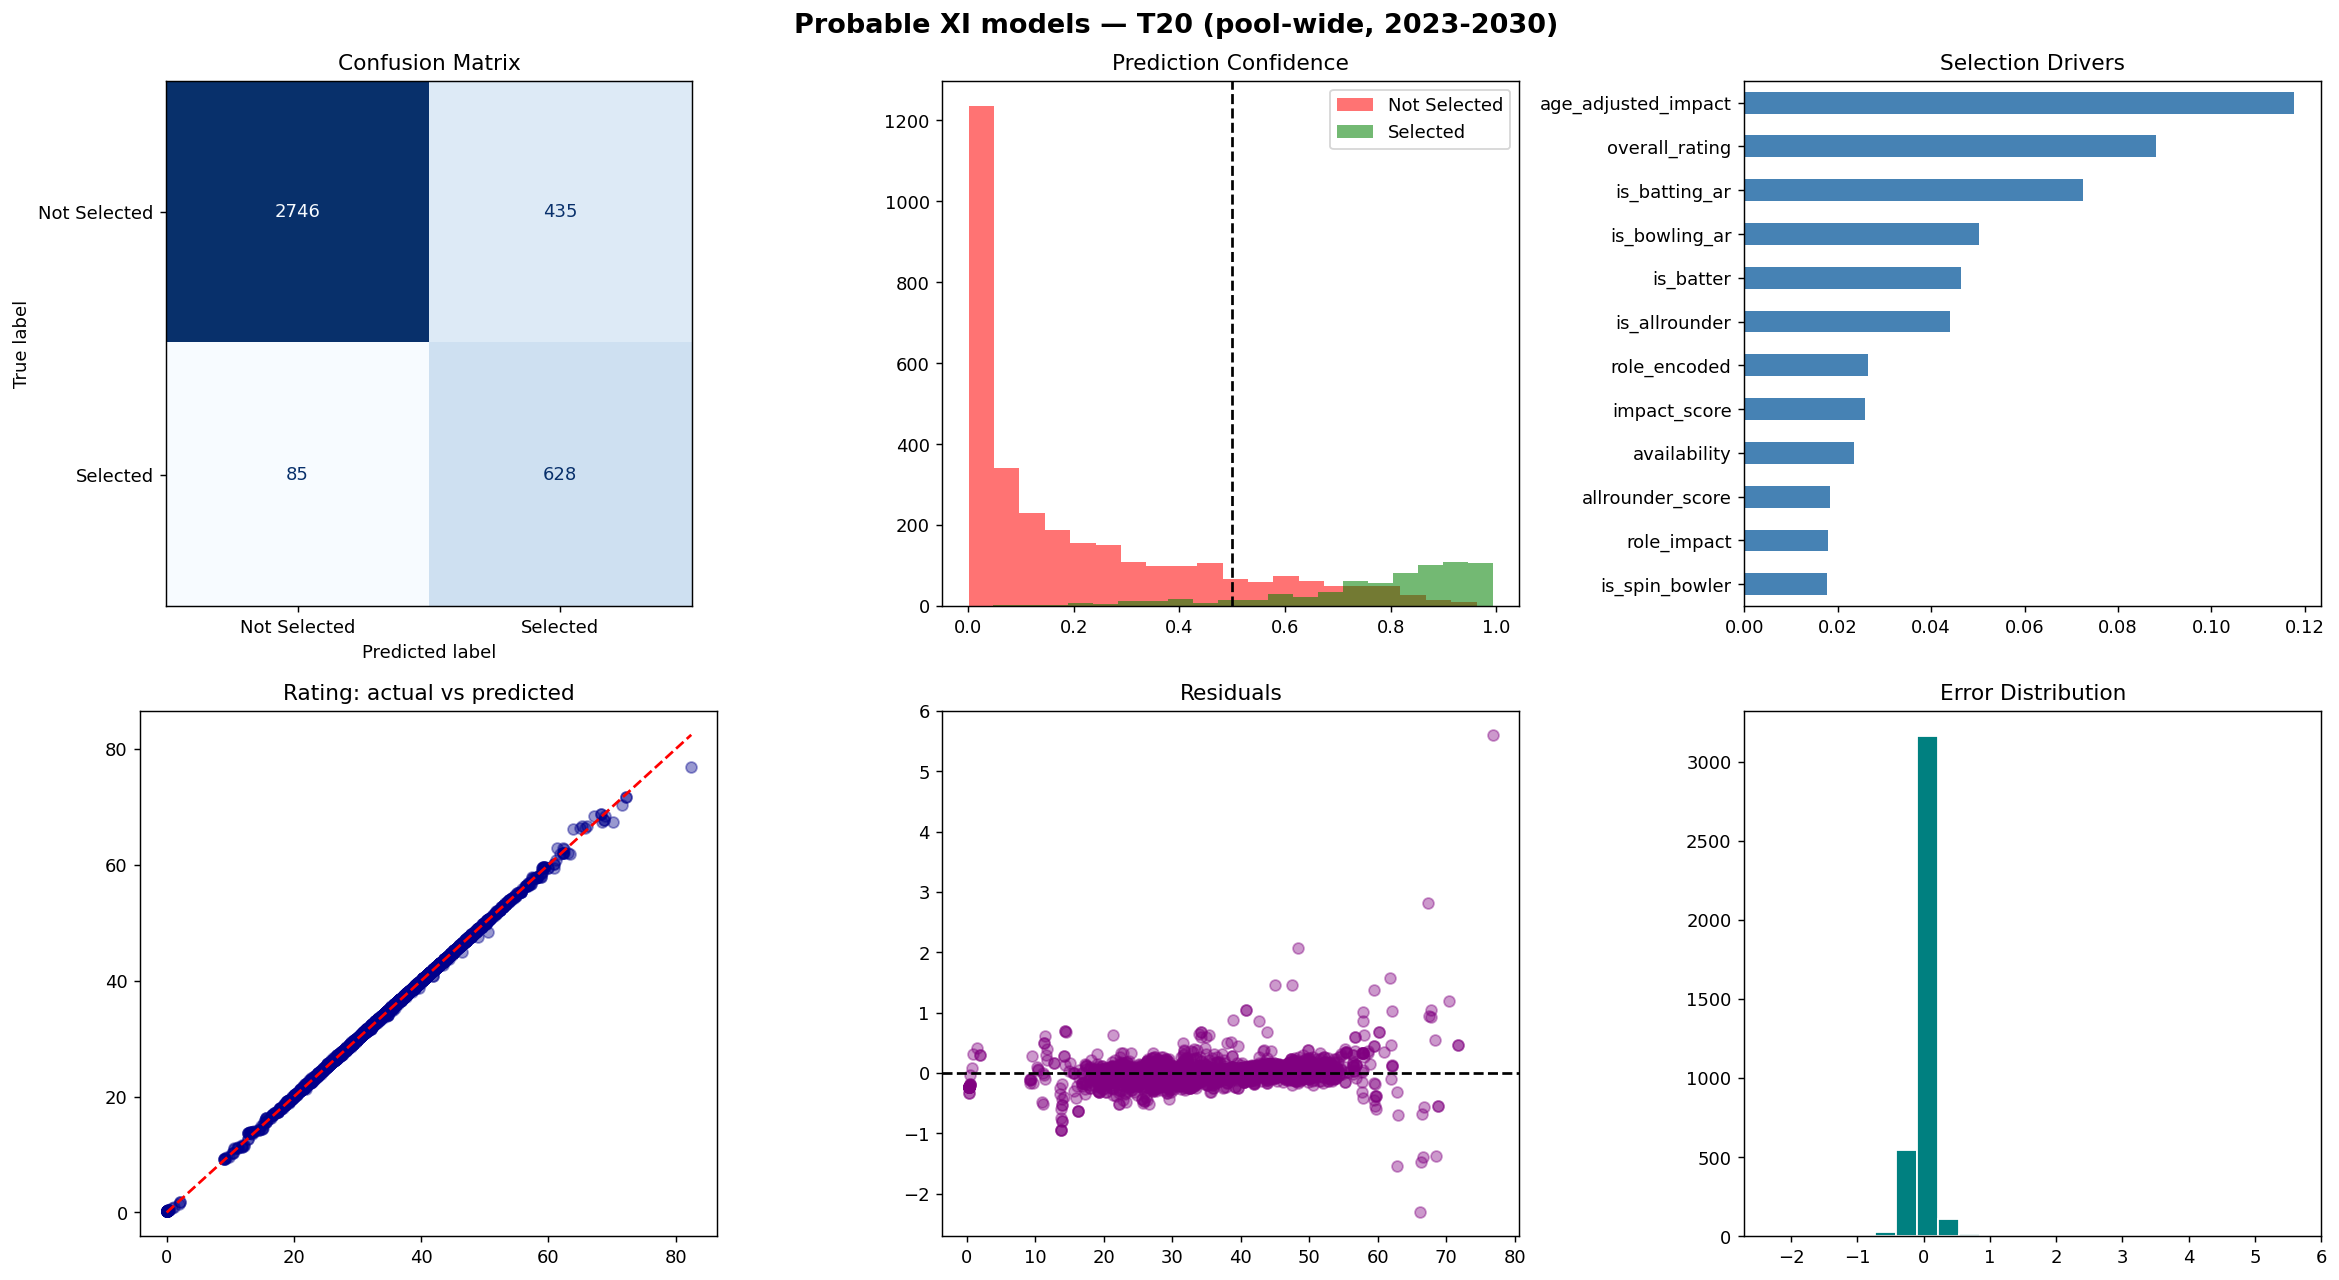


TRAINING — ODI
  rows 19521 | features 66 | positive rate 18.26%

  ODI RESULTS
  ----------------------------------------
  Train accuracy : 0.8992
  Test  accuracy : 0.8686
  Gap            : 0.0305
  ROC-AUC        : 0.9488
  Rating R2      : 0.9990 | MAE 0.100


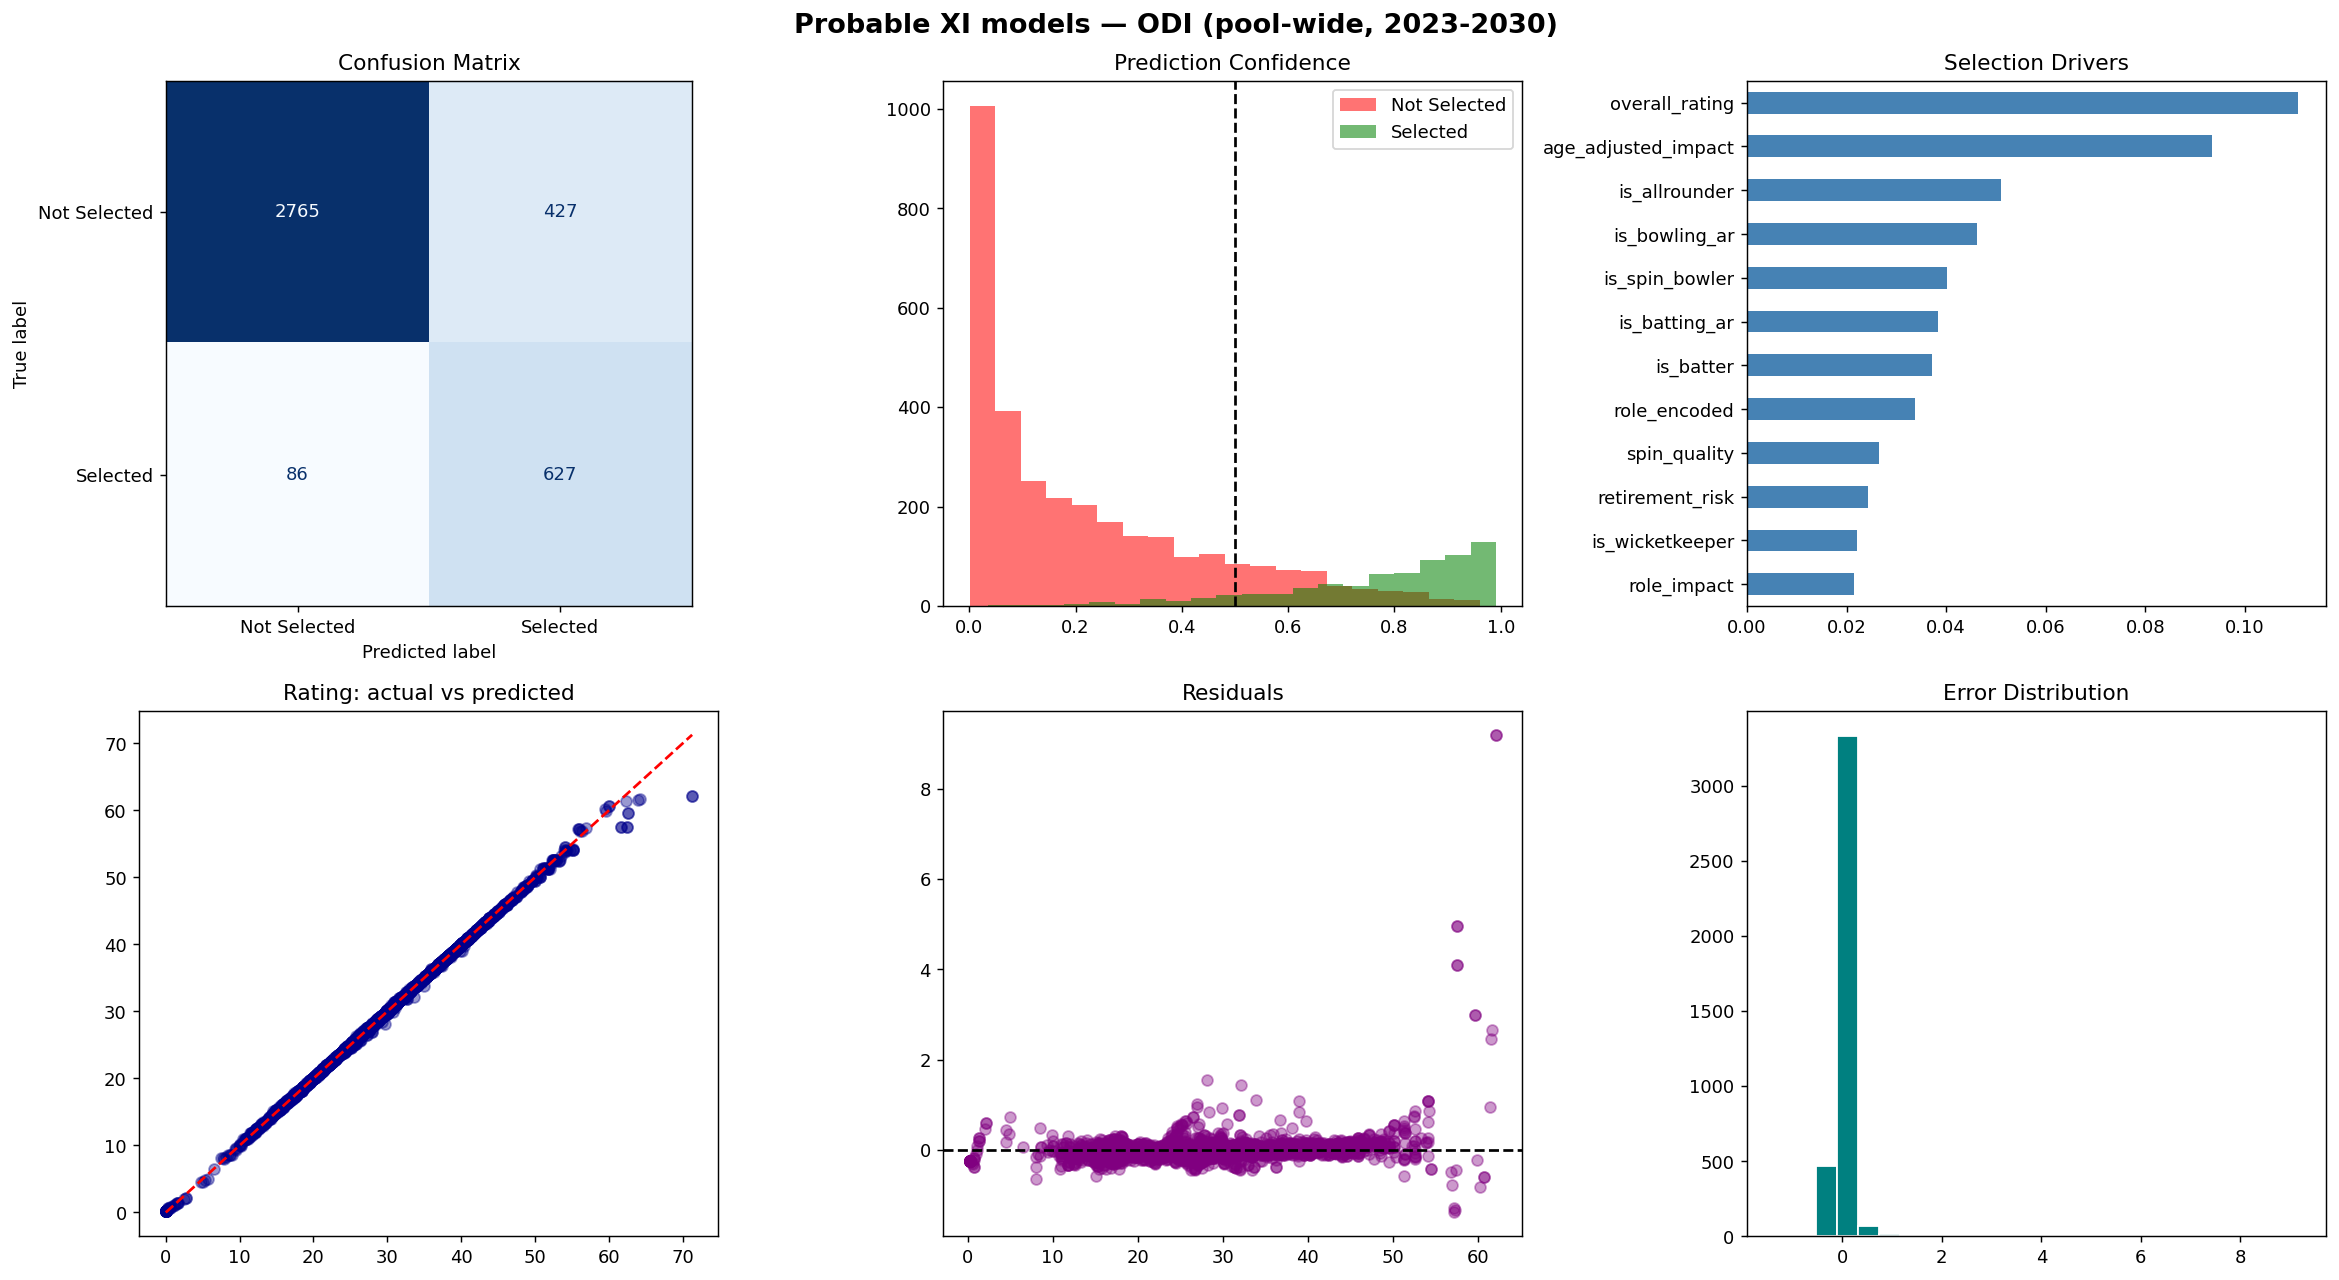


TRAINING — Test
  rows 19143 | features 66 | positive rate 18.62%

  Test RESULTS
  ----------------------------------------
  Train accuracy : 0.9143
  Test  accuracy : 0.8820
  Gap            : 0.0324
  ROC-AUC        : 0.9610
  Rating R2      : 0.9997 | MAE 0.109


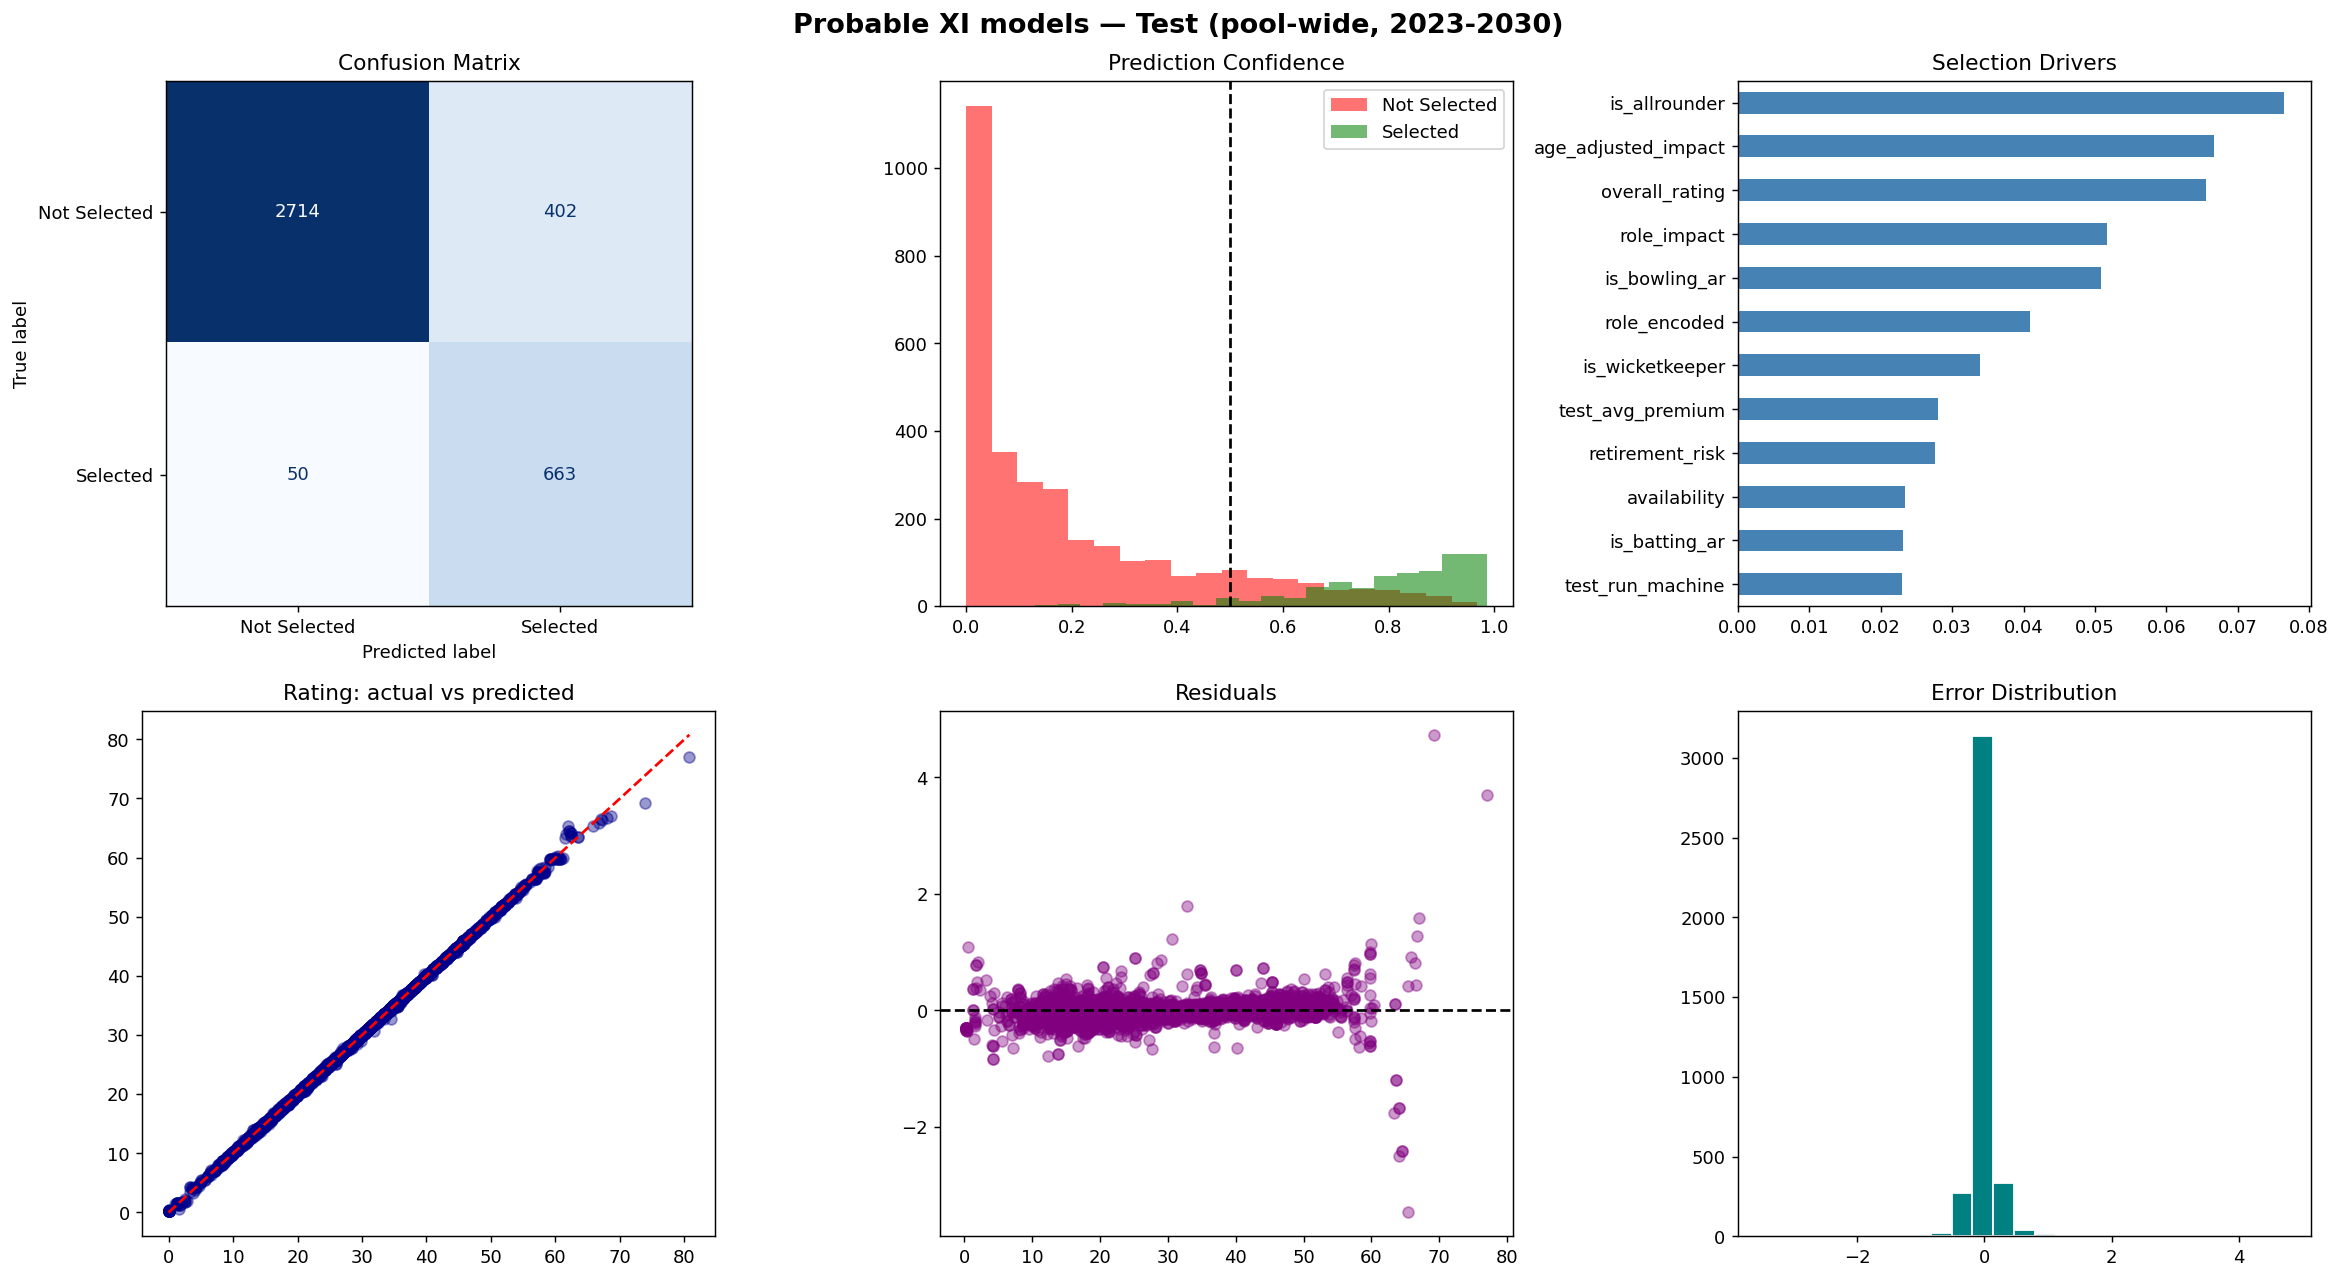


All models trained and saved to D:\R26-IT-096\R26-IT-096\server\microservice-3\python_ml\models_2030


In [8]:
# CELL 8 — TRAIN THE THREE MODELS (T20 / ODI / TEST)
# =============================================================
FORMAT_CONFIGS = {
    "T20" : {"n_estimators": 1200, "max_depth": 4, "learning_rate": 0.010,
             "subsample": 0.80, "colsample_bytree": 0.70, "min_child_weight": 5,
             "gamma": 1.5, "reg_alpha": 1.5, "reg_lambda": 5.0,
             "early_stopping": 80, "test_size": 0.20},
    "ODI" : {"n_estimators": 1200, "max_depth": 4, "learning_rate": 0.010,
             "subsample": 0.80, "colsample_bytree": 0.70, "min_child_weight": 5,
             "gamma": 1.5, "reg_alpha": 1.5, "reg_lambda": 5.0,
             "early_stopping": 80, "test_size": 0.20},
    "Test": {"n_estimators": 1200, "max_depth": 4, "learning_rate": 0.010,
             "subsample": 0.80, "colsample_bytree": 0.70, "min_child_weight": 5,
             "gamma": 1.5, "reg_alpha": 1.5, "reg_lambda": 5.0,
             "early_stopping": 80, "test_size": 0.20},
}
 
 
def native_oversample(X, y, random_state=42):
    rng   = np.random.default_rng(random_state)
    y_np  = y.values
    idx_0 = np.where(y_np == 0)[0]
    idx_1 = np.where(y_np == 1)[0]
    if len(idx_1) == 0 or len(idx_0) == 0:
        return X, y
    if len(idx_1) < len(idx_0):
        extra = rng.choice(idx_1, size=len(idx_0) - len(idx_1), replace=True)
        new   = np.concatenate([np.arange(len(y_np)), extra])
        return X.iloc[new].reset_index(drop=True), y.iloc[new].reset_index(drop=True)
    return X, y
 
 
def plot_charts(clf, y_test_c, y_pred_c, y_prob_c, y_test_r, y_pred_r, fmt):
    plt.close("all")
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Probable XI models — {fmt} (pool-wide, 2023-2030)",
                 fontsize=15, fontweight="bold")
 
    ConfusionMatrixDisplay(confusion_matrix(y_test_c, y_pred_c),
                           display_labels=["Not Selected", "Selected"]
                           ).plot(ax=ax[0, 0], colorbar=False, cmap="Blues")
    ax[0, 0].set_title("Confusion Matrix")
 
    ax[0, 1].hist(y_prob_c[y_test_c == 0], bins=20, alpha=0.55, color="red",   label="Not Selected")
    ax[0, 1].hist(y_prob_c[y_test_c == 1], bins=20, alpha=0.55, color="green", label="Selected")
    ax[0, 1].axvline(0.5, color="black", linestyle="--")
    ax[0, 1].set_title("Prediction Confidence"); ax[0, 1].legend()
 
    names = clf.get_booster().feature_names or [f"F{i}" for i in range(len(clf.feature_importances_))]
    (pd.Series(clf.feature_importances_, index=names)
       .sort_values().tail(12).plot(kind="barh", ax=ax[0, 2], color="steelblue"))
    ax[0, 2].set_title("Selection Drivers")
 
    ax[1, 0].scatter(y_test_r, y_pred_r, alpha=0.4, color="darkblue")
    lims = [min(y_test_r), max(y_test_r)]
    ax[1, 0].plot(lims, lims, "r--"); ax[1, 0].set_title("Rating: actual vs predicted")
 
    res = y_test_r - y_pred_r
    ax[1, 1].scatter(y_pred_r, res, alpha=0.4, color="purple")
    ax[1, 1].axhline(0, color="black", linestyle="--"); ax[1, 1].set_title("Residuals")
 
    ax[1, 2].hist(res, bins=25, color="teal", edgecolor="white")
    ax[1, 2].set_title("Error Distribution")
 
    plt.tight_layout()
    path = os.path.join(MODELS_PATH, f"charts_{fmt.lower()}.png")
    plt.savefig(path, dpi=130, bbox_inches="tight")
    display(Image(filename=path))
    plt.close(fig)
 
 
def train_format(df, fmt):
    print(f"\n{'=' * 62}\nTRAINING — {fmt}\n{'=' * 62}")
    cfg   = FORMAT_CONFIGS[fmt]
    feats = get_feature_list(df, fmt)
 
    X       = df[feats].fillna(0)
    y_class = df["is_in_probable_11"].astype(int)
    y_reg   = df["impact_score"].astype(float)
    print(f"  rows {len(X)} | features {len(feats)} | "
          f"positive rate {y_class.mean():.2%}")
 
    Xtr, Xte, ytr, yte = train_test_split(X, y_class, test_size=cfg["test_size"],
                                          stratify=y_class, random_state=42)
    Xtr, ytr = native_oversample(Xtr, ytr)
    Xtr2, Xval, ytr2, yval = train_test_split(Xtr, ytr, test_size=0.12,
                                              stratify=ytr, random_state=42)
 
    clf = xgb.XGBClassifier(
        n_estimators=cfg["n_estimators"], max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"], subsample=cfg["subsample"],
        colsample_bytree=cfg["colsample_bytree"],
        min_child_weight=cfg["min_child_weight"], gamma=cfg["gamma"],
        reg_alpha=cfg["reg_alpha"], reg_lambda=cfg["reg_lambda"],
        objective="binary:logistic", eval_metric="logloss",
        random_state=42, early_stopping_rounds=cfg["early_stopping"])
    clf.fit(Xtr2, ytr2, eval_set=[(Xval, yval)], verbose=False)
 
    Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X, y_reg, test_size=0.20,
                                                  random_state=42)
    reg = xgb.XGBRegressor(
        n_estimators=600, max_depth=cfg["max_depth"],
        learning_rate=cfg["learning_rate"], subsample=cfg["subsample"],
        colsample_bytree=cfg["colsample_bytree"],
        reg_alpha=cfg["reg_alpha"], reg_lambda=cfg["reg_lambda"],
        random_state=42)
    reg.fit(Xtr_r, ytr_r)
 
    prob_tr = clf.predict_proba(Xtr)[:, 1]
    prob_te = clf.predict_proba(Xte)[:, 1]
    pred_tr = (prob_tr >= 0.5).astype(int)
    pred_te = (prob_te >= 0.5).astype(int)
    tr_acc, te_acc = accuracy_score(ytr, pred_tr), accuracy_score(yte, pred_te)
    auc = roc_auc_score(yte, prob_te)
    pred_r = reg.predict(Xte_r)
 
    print(f"\n  {fmt} RESULTS\n  {'-' * 40}")
    print(f"  Train accuracy : {tr_acc:.4f}")
    print(f"  Test  accuracy : {te_acc:.4f}")
    print(f"  Gap            : {abs(tr_acc - te_acc):.4f}")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  Rating R2      : {r2_score(yte_r, pred_r):.4f} | "
          f"MAE {mean_absolute_error(yte_r, pred_r):.3f}")
 
    plot_charts(clf, yte.values, pred_te, prob_te, yte_r.values, pred_r, fmt)
    return clf, reg, feats
 
 
models = {}
for fmt in FORMATS:
    if labeled[fmt].empty:
        continue
    clf, reg, feats = train_format(labeled[fmt], fmt)
    joblib.dump(clf, os.path.join(MODELS_PATH, f"clf_{fmt.lower()}_2030.pkl"))
    joblib.dump(reg, os.path.join(MODELS_PATH, f"reg_{fmt.lower()}_2030.pkl"))
    models[fmt] = {"clf": clf, "reg": reg, "features": feats}
 
with open(os.path.join(MODELS_PATH, "features_2030.json"), "w") as f:
    json.dump({k: v["features"] for k, v in models.items()}, f, indent=2)
 
print("\nAll models trained and saved to", MODELS_PATH)


SHAP — T20
  SHAP values: (2000, 66)


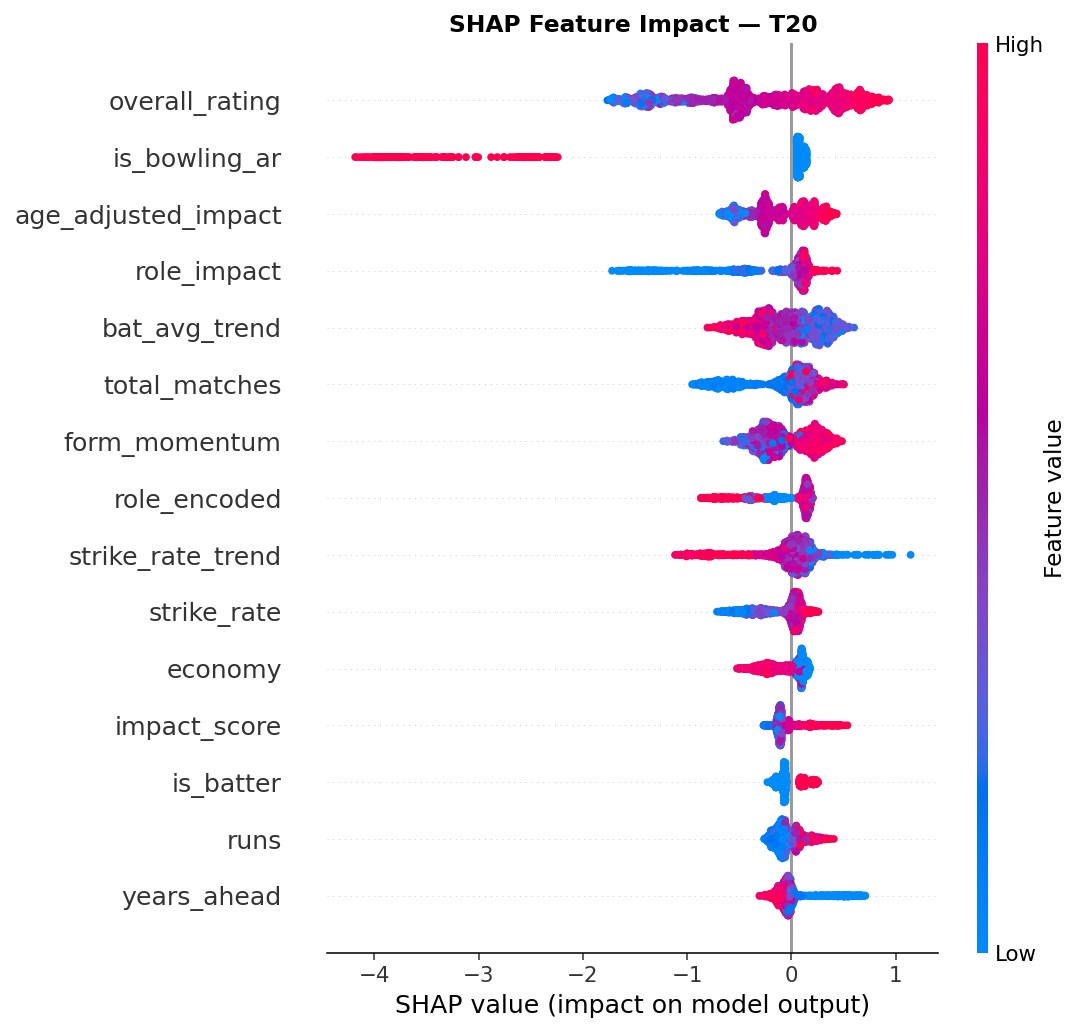

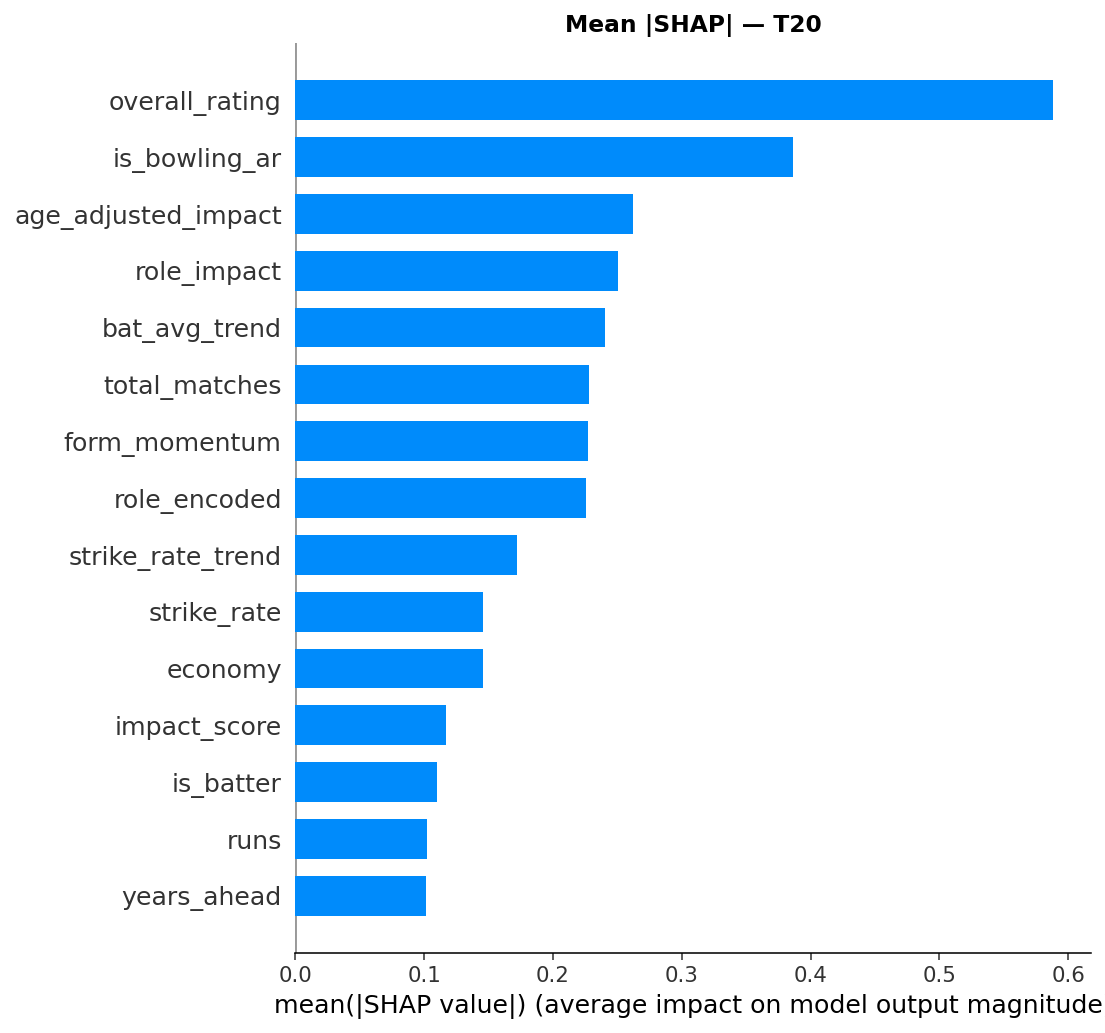

            feature  mean_|shap|
     overall_rating     0.588427
      is_bowling_ar     0.386649
age_adjusted_impact     0.262059
        role_impact     0.250757
      bat_avg_trend     0.240055
      total_matches     0.227915
      form_momentum     0.226832
       role_encoded     0.225364
  strike_rate_trend     0.172102
        strike_rate     0.145653
            economy     0.145438
       impact_score     0.116924

SHAP — ODI
  SHAP values: (2000, 66)


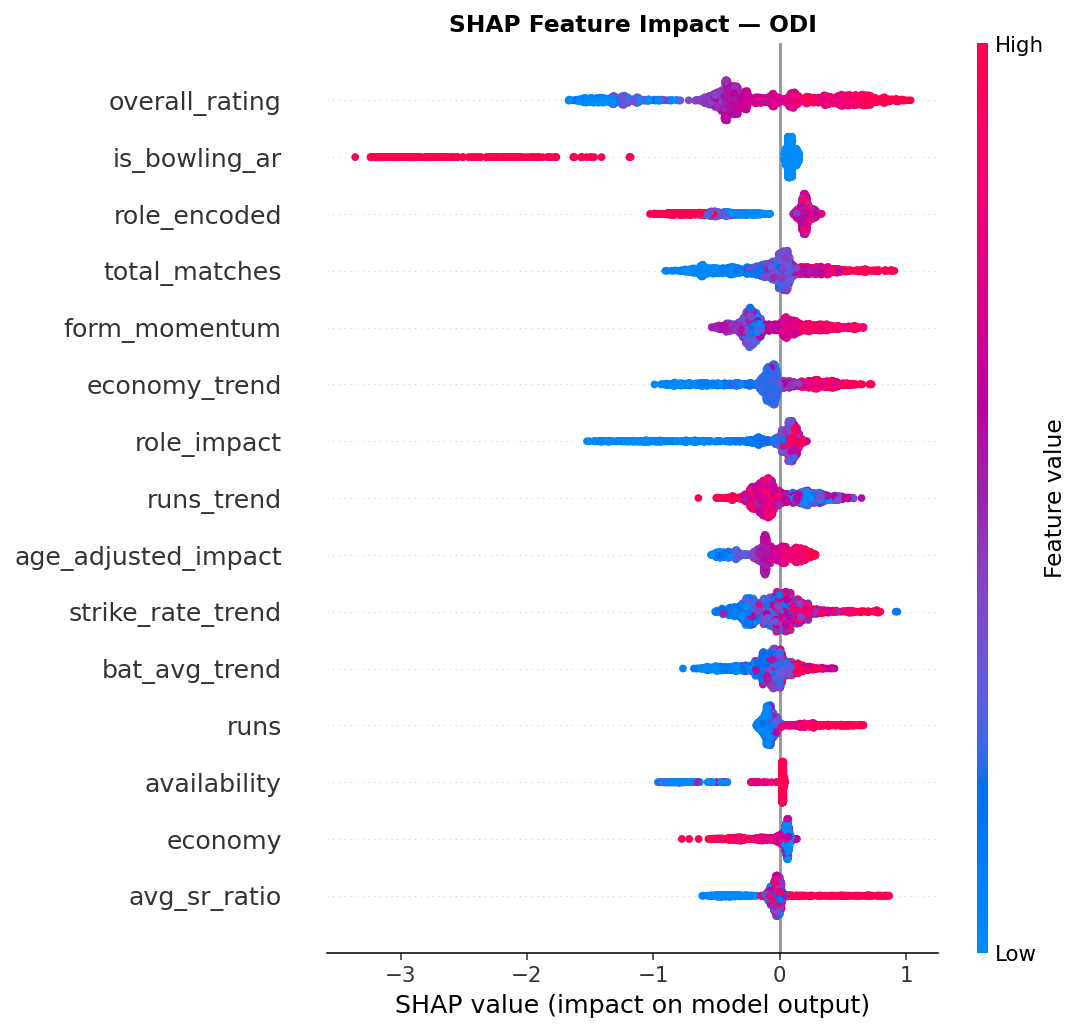

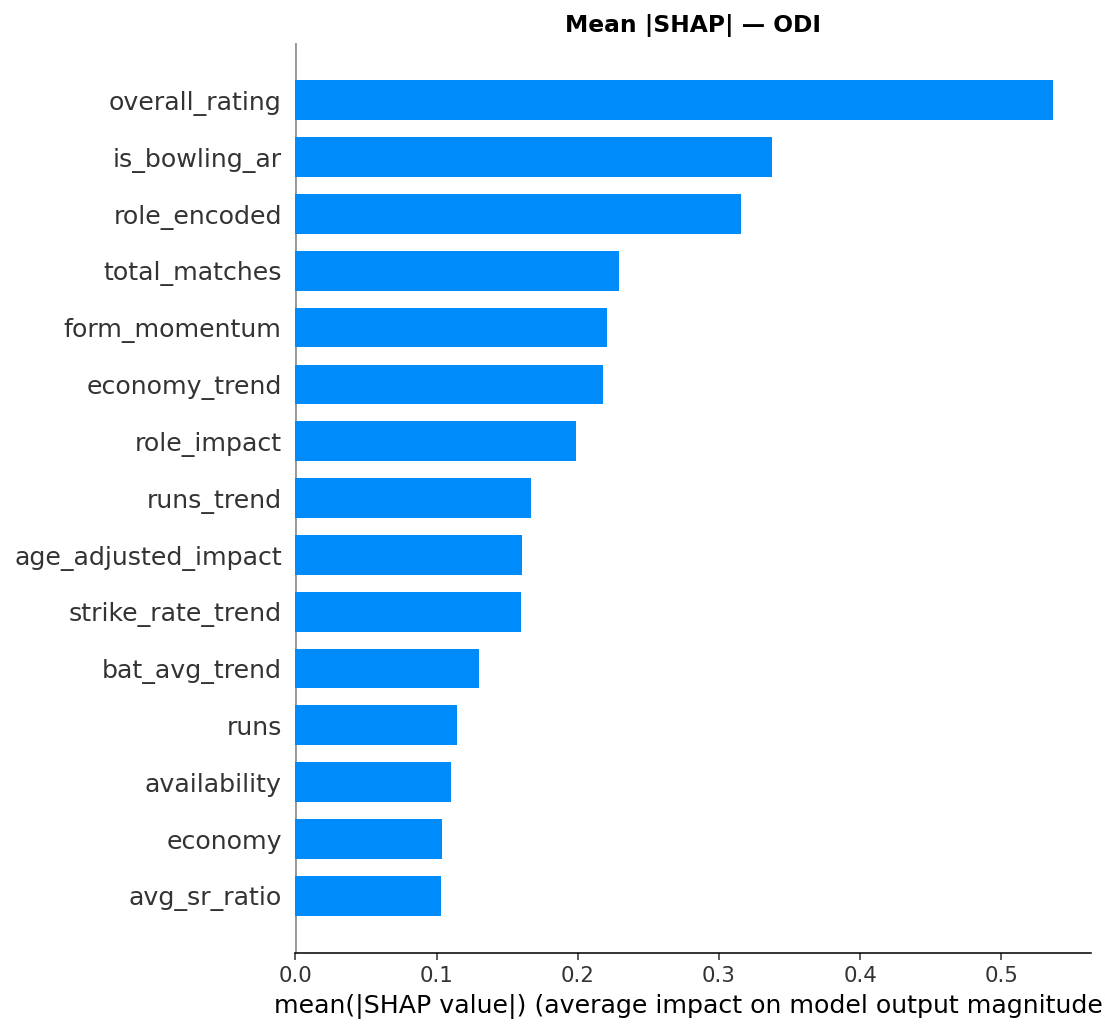

            feature  mean_|shap|
     overall_rating     0.536754
      is_bowling_ar     0.337752
       role_encoded     0.315505
      total_matches     0.229330
      form_momentum     0.220780
      economy_trend     0.217843
        role_impact     0.198955
         runs_trend     0.166643
age_adjusted_impact     0.160754
  strike_rate_trend     0.159967
      bat_avg_trend     0.130250
               runs     0.114362

SHAP — Test
  SHAP values: (2000, 66)


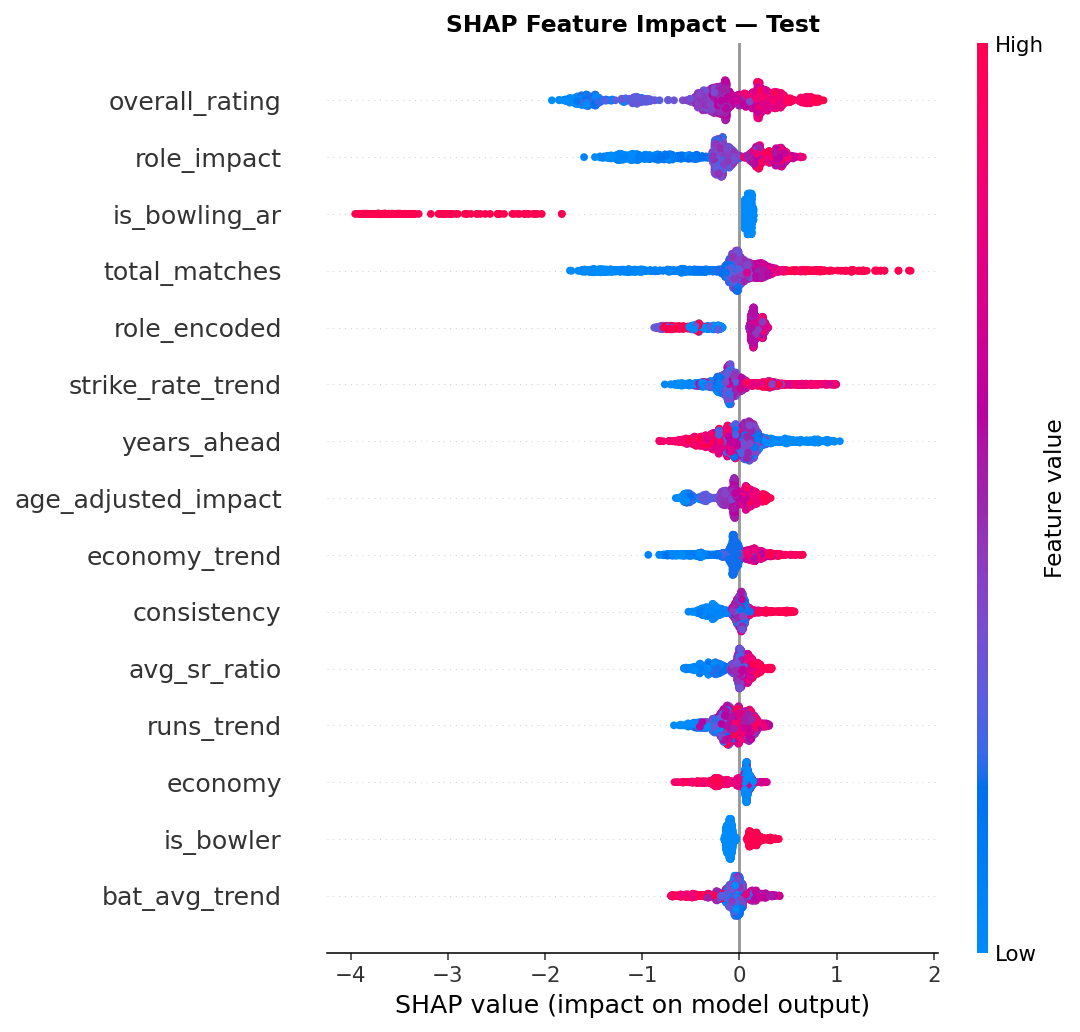

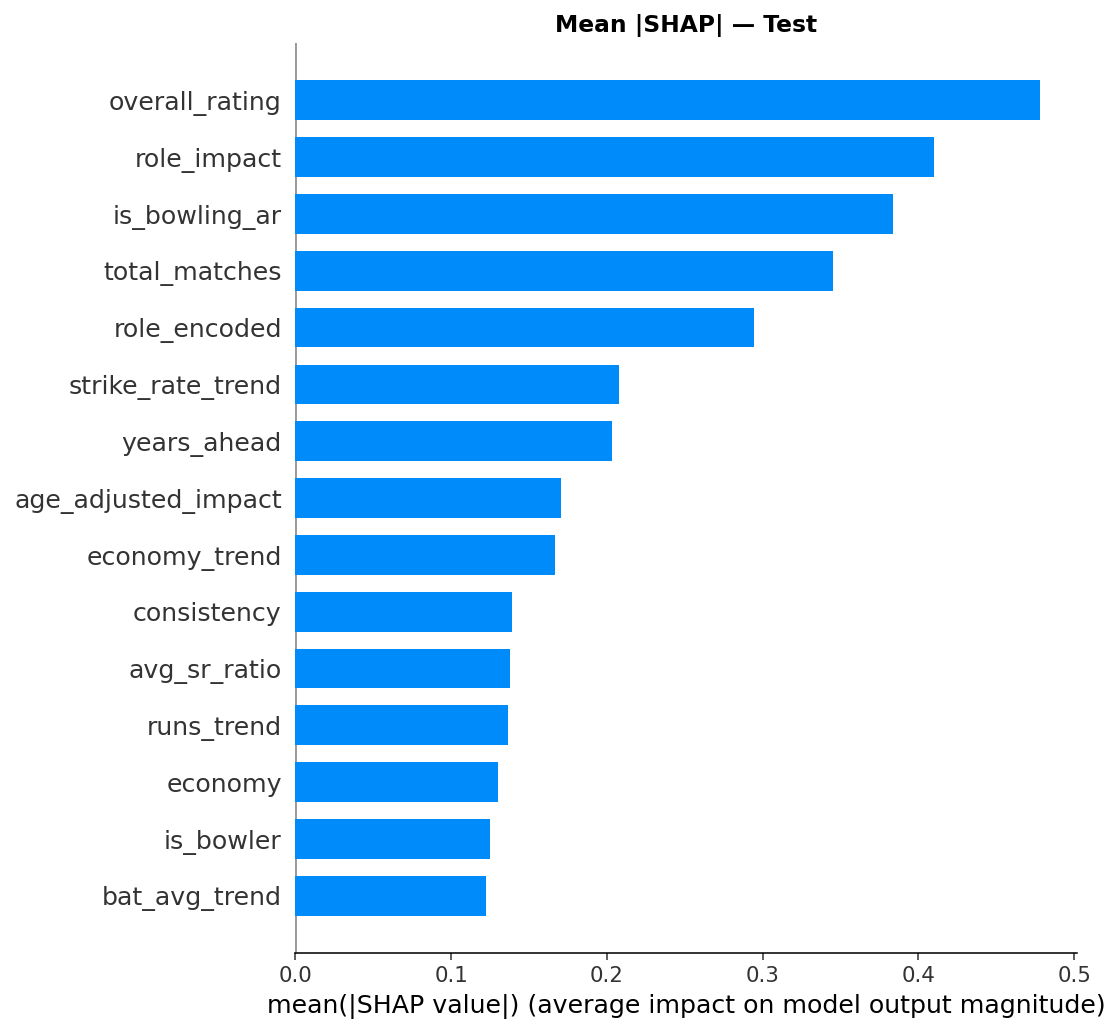

            feature  mean_|shap|
     overall_rating     0.478001
        role_impact     0.409991
      is_bowling_ar     0.383650
      total_matches     0.345456
       role_encoded     0.294567
  strike_rate_trend     0.207847
        years_ahead     0.203272
age_adjusted_impact     0.170424
      economy_trend     0.166450
        consistency     0.138857
       avg_sr_ratio     0.137896
         runs_trend     0.136578

SHAP analysis complete.


In [9]:
# CELL 9 — SHAP EXPLAINABILITY (per format)
# =============================================================
try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print("shap not installed — run:  pip install shap   (cell skipped)")
 
if SHAP_OK:
    explainers = {}
    for fmt in FORMATS:
        if fmt not in models:
            continue
        print(f"\n{'=' * 56}\nSHAP — {fmt}\n{'=' * 56}")
        clf   = models[fmt]["clf"]
        feats = models[fmt]["features"]
 
        sample = labeled[fmt].sample(min(2000, len(labeled[fmt])), random_state=42)
        X = sample[feats].fillna(0)
        book = clf.get_booster().feature_names
        if book:
            for f in book:
                if f not in X.columns:
                    X[f] = 0.0
            X = X[book]
 
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X)
        sv = sv[1] if isinstance(sv, list) else sv
        print(f"  SHAP values: {sv.shape}")
 
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sv, X, plot_type="dot", show=False, max_display=15)
        plt.title(f"SHAP Feature Impact — {fmt}", fontweight="bold")
        p1 = os.path.join(MODELS_PATH, f"shap_summary_{fmt.lower()}.png")
        plt.tight_layout(); plt.savefig(p1, dpi=140, bbox_inches="tight")
        display(Image(filename=p1)); plt.close()
 
        plt.figure(figsize=(10, 6))
        shap.summary_plot(sv, X, plot_type="bar", show=False, max_display=15)
        plt.title(f"Mean |SHAP| — {fmt}", fontweight="bold")
        p2 = os.path.join(MODELS_PATH, f"shap_bar_{fmt.lower()}.png")
        plt.tight_layout(); plt.savefig(p2, dpi=140, bbox_inches="tight")
        display(Image(filename=p2)); plt.close()
 
        imp = (pd.DataFrame({"feature": X.columns,
                             "mean_|shap|": np.abs(sv).mean(axis=0)})
               .sort_values("mean_|shap|", ascending=False).head(12))
        print(imp.to_string(index=False))
 
        joblib.dump(explainer, os.path.join(MODELS_PATH, f"explainer_{fmt.lower()}_2030.pkl"))
        explainers[fmt] = explainer
    print("\nSHAP analysis complete.")
 

In [10]:
# CELL 9.5 — LOAD KNOWN LINEUPS (JSON) + NAME MATCHING
# =============================================================
# lineups_<fmt>.json shape:  { team : { opponent : [11 names] } }
# =============================================================
from collections import Counter


def _norm_name(s):
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def _name_keys(s):
    """Full name + 'lastname initial' variants so 'M Marsh' == 'Mitchell Marsh'."""
    n = _norm_name(s)
    if not n:
        return set()
    parts = n.split()
    keys = {n}
    if len(parts) >= 2:
        keys.add(f"{parts[-1]} {parts[0][0]}")
        keys.add(f"{parts[0][0]} {parts[-1]}")
    return keys


def _match_key(target, candidates):
    """Case/substring tolerant key lookup (team or opponent names)."""
    t = str(target).lower().strip()
    cands = list(candidates)
    for c in cands:
        if str(c).lower().strip() == t:
            return c
    for c in cands:
        cl = str(c).lower().strip()
        if t and (t in cl or cl in t):
            return c
    return None


def load_lineups(fmt):
    path = os.path.join(EXPORT_PATH, LINEUP_JSON[fmt])
    if not os.path.exists(path):
        print(f"  MISSING lineup file: {path}")
        return {}
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    n_pairs = sum(len(v) if isinstance(v, dict) else 1 for v in data.values())
    print(f"  {fmt:<5} {len(data):>3} teams | {n_pairs:>4} team-vs-opponent lineups")
    return data


print("=" * 62)
print("LOADING KNOWN LINEUPS")
print("=" * 62)
lineups = {fmt: load_lineups(fmt) for fmt in FORMATS}


def lineup_requirement(year):
    """How many XI slots must be filled from the known lineup that year."""
    return int(LINEUP_MIN_BY_YEAR.get(int(year), 0))


def get_lineup_names(fmt, team, opponent, lineup_dict=None):
    """Names for team-vs-opponent; falls back to that team's most-used XI."""
    d = lineup_dict if lineup_dict is not None else lineups.get(fmt, {})
    if not d:
        return []
    tkey = _match_key(team, d.keys())
    if tkey is None:
        return []
    block = d[tkey]
    if isinstance(block, list):                 # flat list, no opponent split
        return [str(x) for x in block]
    okey = _match_key(opponent, block.keys())
    if okey is not None:
        return [str(x) for x in block[okey]]
    c = Counter()
    for v in block.values():
        for p in v:
            c[str(p)] += 1
    return [n for n, _ in c.most_common(11)]


def match_lineup_positions(pool, names):
    """{pool_index: batting_position} — position is the name's place in the
    lineup list, i.e. index 0 in the JSON means he opens at 1."""
    if not names:
        return {}
    key_to_pos = {}
    for pos, n in enumerate(names, start=1):
        for k in _name_keys(n):
            key_to_pos.setdefault(k, pos)
    out = {}
    for i, nm in zip(pool.index, pool["player_name"]):
        hits = [key_to_pos[k] for k in _name_keys(nm) if k in key_to_pos]
        if hits:
            out[i] = min(hits)
    return out


def match_lineup_indices(pool, names):
    return list(match_lineup_positions(pool, names).keys())


def role_group(role):
    if role == "Wicketkeeper":
        return "wk"
    if role in ROLE_BOWL:
        return "bowl"
    if "All-Rounder" in str(role):
        return "ar"
    return "bat"


# quick sanity check
for fmt in FORMATS:
    if not lineups[fmt]:
        continue
    t = list(lineups[fmt].keys())[0]
    o = list(lineups[fmt][t].keys())[0] if isinstance(lineups[fmt][t], dict) else "-"
    nm = get_lineup_names(fmt, t, o)
    print(f"  sample {fmt} {t} vs {o}: {len(nm)} names -> {', '.join(nm[:4])} ...")

LOADING KNOWN LINEUPS
  T20    12 teams |  132 team-vs-opponent lineups
  ODI    12 teams |  132 team-vs-opponent lineups
  Test   12 teams |  133 team-vs-opponent lineups
  sample T20 Afghanistan vs Australia: 11 names -> Rahmanullah Gurbaz, Ibrahim Zadran, Sediqullah Atal, Azmatullah Omarzai ...
  sample ODI Afghanistan vs Australia: 11 names -> R. Gurbaz, Ibrahim Zadran, Rahmat Shah, H. Shahidi ...
  sample Test Afghanistan vs Australia: 11 names -> Ibrahim Zadran, Sediqullah Atal, Rahmat Shah, H. Shahidi ...


In [11]:
# CELL 10 — PROBABLE XI PREDICTOR
#   venue-aware bowler quota + near-term experience + LINEUP FLOOR
# =============================================================
# Batting order: strict role buckets (top order -> middle order/keeper
# -> batting all-rounder -> all-rounder/bowling all-rounder -> bowlers).
# A retained lineup player never jumps a bucket — his lineup_pos only
# breaks ties against other players inside the SAME bucket.
#
# Bowler split (out of n_bowlers, default 4):
#   pace-friendly : 3 pace + 1 slot filled by Spin Bowler, falling back
#                   to Bowling All-Rounder if no spin bowler is free
#   spin-friendly : 2 pace + 2 slots filled by Spin Bowler first,
#                   falling back to Bowling All-Rounder for any
#                   unfilled slot (so it can land as 2 spin, or
#                   1 spin + 1 bowling all-rounder)
#   balanced      : split down the middle as before
# =============================================================
_period_cache = {}


def _half_wobble(name, year, half, spread=0.06):
    h = int(hashlib.md5(f"{name}|{year}|{half}".encode("utf-8")).hexdigest()[:8], 16)
    return 1.0 + ((h % 1000) / 999.0 * 2 - 1) * spread


def near_term_boost(row, year):
    if int(year) not in NEAR_TERM_YEARS:
        return 1.0
    years_ahead = max(0, int(year) - BASE_YEAR)
    decay = max(0.0, 1 - years_ahead / NEAR_TERM_DECAY_YEARS)
    exp_norm = min(float(row.get("total_matches", 0)) / EXPERIENCE_MATCHES_CAP, 1.0)
    fm = float(row.get("form_momentum", 0.0))
    form_norm = (np.clip(fm, -1, 1) + 1) / 2
    return 1 + NEAR_TERM_EXPERIENCE_WEIGHT * decay * (0.7 * exp_norm + 0.3 * form_norm)


def get_period_frame(fmt, year, period="H1"):
    half = resolve_period(period)
    key  = (fmt, int(year), half)
    if key in _period_cache:
        return _period_cache[key]

    w   = HALVES[half]
    raw = panels[fmt]
    cur = raw[raw["year"] == int(year)].copy()
    if cur.empty:
        _period_cache[key] = cur
        return cur

    nxt = raw[raw["year"] == int(year) + 1].set_index(["player_name", "team"])
    cur = cur.set_index(["player_name", "team"])
    blend_cols = METRICS + ["age", "availability", "total_matches"]

    if not nxt.empty:
        nxt = nxt.reindex(cur.index)
        for c in blend_cols:
            if c in cur.columns and c in nxt.columns:
                cur[c] = cur[c] * (1 - w) + nxt[c].fillna(cur[c]) * w
    else:
        cur["age"] = cur["age"] + w

    cur = cur.reset_index()
    wob = np.array([_half_wobble(n, year, half) for n in cur["player_name"]])
    for c in ["runs", "wickets", "bat_avg", "strike_rate"]:
        cur[c] = (cur[c] * wob).round(2)
    for c in ["economy", "bowl_avg"]:
        cur[c] = (cur[c] / wob).round(2)

    cur["year"]         = int(year)
    cur["period"]       = half
    cur["period_label"] = HALF_LABELS[half]
    cur["years_ahead"]  = int(year) - BASE_YEAR + w
    cur["is_available"] = (cur["availability"] > 0).astype(int)

    frame = engineer_features(cur, fmt)
    _period_cache[key] = frame
    return frame


def get_opponent_profile(opponent, fmt, year, period="H1", frame=None):
    df  = get_period_frame(fmt, year, period) if frame is None else frame
    opp = df[(df["team"] == opponent) & (df["is_available"] == 1)]
    prof = {"opp_spin_vulnerable": False, "opp_pace_vulnerable": False,
            "opp_batting_strength": "average", "opp_avg_bat_avg": 25.0}
    if opp.empty:
        return prof
    bat_roles = ["Top Order Batter", "Middle Order Batter", "Batter",
                 "Wicketkeeper", "Batting All-Rounder", "All-Rounder"]
    top = opp[opp["role"].isin(bat_roles)].nlargest(6, "bat_avg")
    if top.empty:
        return prof

    mean_avg = float(top["bat_avg"].mean())
    prof["opp_avg_bat_avg"] = round(mean_avg, 2)
    strong = {"T20": 28, "ODI": 35, "Test": 42}[fmt]
    weak   = {"T20": 18, "ODI": 25, "Test": 30}[fmt]
    prof["opp_batting_strength"] = ("strong" if mean_avg >= strong
                                    else "weak" if mean_avg <= weak else "average")
    sr_floor = {"T20": 110, "ODI": 70, "Test": 45}[fmt]
    prof["opp_spin_vulnerable"] = bool((top["strike_rate"] < sr_floor).sum() >= 3)
    prof["opp_pace_vulnerable"] = bool(((top["bat_avg"] < weak) &
                                        (top["strike_rate"] > sr_floor)).sum() >= 2)
    return prof


def venue_bowler_plan(is_high, is_low, is_spin, is_pace):
    """-> (n_bowlers, n_pace, n_flex_spin, include_bat_ar, extra_batting, extra_bowling)
    n_flex_spin slots are filled Spin Bowler first, Bowling All-Rounder as fallback."""
    if is_low:
        n_bowlers, extra_batting, extra_bowling, include_bat_ar = (
            BOWLER_QUOTA["low_scoring"], LOW_SCORING_EXTRA_BATTER, 0, True)
    elif is_high:
        n_bowlers, extra_batting, extra_bowling, include_bat_ar = (
            BOWLER_QUOTA["high_scoring"], 0, HIGH_SCORING_EXTRA_BOWLER, False)
    else:
        n_bowlers, extra_batting, extra_bowling, include_bat_ar = (
            BOWLER_QUOTA["default"], 0, 0, True)

    if is_pace and not is_spin:
        # pace-heavy: 3 of 4 pace, the rest is a spin-or-AR flex slot
        n_pace = max(1, round(n_bowlers * PACE_SPIN_SKEW))
        n_flex_spin = max(0, n_bowlers - n_pace)
    elif is_spin and not is_pace:
        # spin-friendly: even split, both non-pace slots are spin-or-AR flex
        n_pace = n_bowlers // 2
        n_flex_spin = n_bowlers - n_pace
    else:
        n_pace = n_bowlers - n_bowlers // 2
        n_flex_spin = n_bowlers // 2

    return n_bowlers, n_pace, n_flex_spin, include_bat_ar, extra_batting, extra_bowling


def assign_batting_order(xi):
    """Strict role buckets: top order -> middle order/keeper -> batting AR
    -> all-rounder/bowling AR -> bowlers. Inside a bucket, a retained
    lineup player (from_lineup) sorts first, ordered by his known
    lineup_pos; new faces follow, ordered by probability. lineup_pos
    only ever breaks a tie within a bucket — it can't move a player
    into an earlier bucket than his role allows."""
    xi = xi.copy()
    order, used = [], set()

    def take_sorted(frame, n=None):
        if frame.empty:
            return
        f = frame.copy()
        f["_new"] = 1 - f.get("from_lineup", 0)
        lp = f.get("lineup_pos", 0)
        f["_lp"] = lp.where(lp > 0, 999) if hasattr(lp, "where") else 999
        f = f.sort_values(["_new", "_lp", "probability"], ascending=[True, True, False])
        idx = f.index.tolist()
        idx = idx if n is None else idx[:n]
        for i in idx:
            if i not in used:
                order.append(i)
                used.add(i)

    # 1) Top order — positions 1-3
    take_sorted(xi[xi["role"] == "Top Order Batter"], 3)
    if len(order) < 3:
        take_sorted(xi[(~xi.index.isin(used)) & (xi["role"] == "Batter")], 3 - len(order))

    # 2) Middle order block — keeper / middle order / flex batter
    take_sorted(xi[(~xi.index.isin(used)) &
                   xi["role"].isin(["Middle Order Batter", "Batter", "Wicketkeeper"])])

    # 3) Batting all-rounder — always after top AND middle order
    take_sorted(xi[(~xi.index.isin(used)) & (xi["role"] == "Batting All-Rounder")])

    # 4) All-rounder / bowling all-rounder
    take_sorted(xi[(~xi.index.isin(used)) & (xi["role"] == "All-Rounder")])
    take_sorted(xi[(~xi.index.isin(used)) & (xi["role"] == "Bowling All-Rounder")])

    # 5) Specialist bowlers
    take_sorted(xi[(~xi.index.isin(used)) & xi["role"].isin(ROLE_BOWL)])

    # anything left over
    take_sorted(xi[~xi.index.isin(used)])

    out = xi.loc[order].copy()
    out["batting_position"] = range(1, len(out) + 1)
    return out


def get_probable_11(team, opponent, fmt, venue, year, period="H1",
                    lineup_dict=None, verbose=False):
    half  = resolve_period(period)
    frame = get_period_frame(fmt, year, half)
    if frame.empty:
        print(f"  WARNING: no {fmt} panel rows for {year}")
        return []

    pool = frame[frame["team"] == team].copy()
    if pool.empty:
        print(f"  WARNING: no {fmt} players for '{team}' in {year}")
        return []

    retired = pool[pool["is_available"] == 0]["player_name"].tolist()
        # ── hard age cap (e.g. nobody over 36 in 2030) ───────────
    cap = HARD_AGE_CAP.get(int(year))
    if cap is not None:
        too_old = pool[pool["age"] > cap]["player_name"].tolist()
        pool = pool[pool["age"] <= cap].copy()
        retired = retired + too_old
    pool = pool[pool["is_available"] == 1].copy()
    pool = pool.drop_duplicates(subset=["player_name"], keep="first").reset_index(drop=True)
    if pool.empty:
        print(f"  WARNING: every {team} player has aged out by {year}")
        return []

    clf   = models[fmt]["clf"]
    feats = models[fmt]["features"]
    book  = clf.get_booster().feature_names or feats
    for f in book:
        if f not in pool.columns:
            pool[f] = 0.0
    pool["probability"] = clf.predict_proba(pool[book].fillna(0))[:, 1].astype(np.float64)
    pool["rating"] = models[fmt]["reg"].predict(pool[book].fillna(0)).round(2)

    # ── venue + opponent + near-term-experience adjustments ──
    is_high, is_low, is_spin, is_pace = classify_conditions(venue, fmt)
    assist = venue.get("pitch_assist", "Unknown")
    ptype  = venue.get("pitch_type", "")
    opp    = get_opponent_profile(opponent, fmt, year, half, frame=frame)

    for idx, row in pool.iterrows():
        boost = bowler_pitch_boost(row["role"], assist, ptype)
        if row["role"] == "Spin Bowler" and opp["opp_spin_vulnerable"]:
            boost *= 1.10
        if row["role"] == "Pace Bowler" and opp["opp_pace_vulnerable"]:
            boost *= 1.10
        boost *= (0.80 + 0.20 * row["availability"])
        if row["rising"] == 1:
            boost *= 1.05
        if row["declining"] == 1:
            boost *= 0.94
        boost *= near_term_boost(row, year)
        pool.at[idx, "probability"] = row["probability"] * boost

    if is_high:
        m = pool["role"].isin(["Top Order Batter", "Middle Order Batter",
                               "Batter", "Batting All-Rounder", "Wicketkeeper"])
        pool.loc[m, "probability"] *= 1.05
    pool["probability"] = pool["probability"].clip(0.01, 0.99)

    # ── lineup floor for this year ───────────────────────────
    lineup_names = get_lineup_names(fmt, team, opponent, lineup_dict)
    lineup_pos   = match_lineup_positions(pool, lineup_names)
    lineup_idx   = list(lineup_pos.keys())
    lineup_set   = set(lineup_idx)
    required     = lineup_requirement(year)
    required_eff = min(required, len(lineup_idx))

    selected = []

    def taken_from_lineup():
        return sum(1 for i in selected if i in lineup_set)

    def pick(roles, count, restrict=None):
        if count <= 0:
            return 0
        mask = pool["role"].isin(roles) & ~pool.index.isin(selected)
        if restrict is not None:
            mask &= pool.index.isin(restrict)
        picks = pool[mask].nlargest(count, "probability").index.tolist()
        selected.extend(picks)
        return len(picks)

    def fill(roles, count):
        if count <= 0:
            return 0
        got = 0
        need = required_eff - taken_from_lineup()
        if need > 0:
            got += pick(roles, min(count, need), restrict=lineup_idx)
        if got < count:
            got += pick(roles, count - got)
        return got

    def have(roles):
        return sum(1 for i in selected if pool.loc[i, "role"] in roles)

    # ── venue-aware bowler plan ──────────────────────────────
    n_bowlers, n_pace, n_flex_spin, include_bat_ar, extra_batting, extra_bowling = \
        venue_bowler_plan(is_high, is_low, is_spin, is_pace)

    if opp["opp_spin_vulnerable"] and not (is_pace and not is_spin) and n_pace > 0:
        n_flex_spin, n_pace = n_flex_spin + 1, n_pace - 1
    elif opp["opp_pace_vulnerable"] and not (is_spin and not is_pace) and n_flex_spin > 0:
        n_pace, n_flex_spin = n_pace + 1, n_flex_spin - 1

    fill(["Wicketkeeper"], 1)

    need_top = max(0, 3 - have(ROLE_TOP))
    got = fill(ROLE_TOP, need_top)
    fill(ROLE_FLEX, need_top - got)

    need_mid = max(0, 2 - have(ROLE_MID))
    got = fill(ROLE_MID, need_mid)
    fill(ROLE_FLEX, need_mid - got)

    if include_bat_ar:
        fill(ROLE_BAT_AR, max(0, 1 - have(ROLE_BAT_AR)))

    fill(["Pace Bowler", "Bowler"], max(0, n_pace - have(["Pace Bowler", "Bowler"])))

    # flex-spin slots: Spin Bowler first, Bowling All-Rounder as fallback
    need_flex = max(0, n_flex_spin - have(["Spin Bowler", "Bowling All-Rounder"]))
    got_flex = fill(["Spin Bowler"], need_flex)
    if got_flex < need_flex:
        fill(["Bowling All-Rounder"], need_flex - got_flex)

    if extra_bowling > 0:
        got = fill(["Bowling All-Rounder"], extra_bowling)
        if got < extra_bowling:
            fill(["Bowler", "Pace Bowler", "Spin Bowler"], extra_bowling - got)

    if extra_batting > 0:
        fill(ROLE_TOP + ROLE_MID + ROLE_FLEX + ROLE_BAT_AR, extra_batting)

    bowl_total = have(ROLE_BOWL) + have(["Bowling All-Rounder"])
    if bowl_total < n_bowlers:
        roles = (["Spin Bowler", "Pace Bowler", "Bowler", "Bowling All-Rounder"] if is_spin
                 else ["Pace Bowler", "Bowler", "Spin Bowler", "Bowling All-Rounder"])
        fill(roles, n_bowlers - bowl_total)

    if len(selected) < 11:
        if is_high:
            fill(["Bowling All-Rounder", "Bowler", "Pace Bowler", "Spin Bowler"], 1)
        elif is_low:
            fill(ROLE_TOP + ROLE_MID + ROLE_FLEX + ROLE_BAT_AR, 1)
        else:
            fill(ROLE_BAT_AR + ["All-Rounder", "Bowling All-Rounder"], 1)
    if len(selected) < 11:
        need = 11 - len(selected)
        short = required_eff - taken_from_lineup()
        if short > 0:
            rest = pool[(~pool.index.isin(selected)) & (pool.index.isin(lineup_idx))] \
                       .nlargest(min(need, short), "probability")
            selected.extend(rest.index.tolist())
    if len(selected) < 11:
        rest = pool[~pool.index.isin(selected)].nlargest(11 - len(selected), "probability")
        selected.extend(rest.index.tolist())

    seen = set()
    selected = [i for i in selected if not (i in seen or seen.add(i))][:11]

    # ── enforce the floor by swapping the weakest outsiders out ──
    if taken_from_lineup() < required_eff:
        spares = pool.loc[[i for i in lineup_idx if i not in selected]] \
                     .sort_values("probability", ascending=False).index.tolist()
        for cand in spares:
            if taken_from_lineup() >= required_eff:
                break
            outsiders = sorted([i for i in selected if i not in lineup_set],
                               key=lambda i: pool.at[i, "probability"])
            if not outsiders:
                break
            cg = role_group(pool.at[cand, "role"])
            target = next((o for o in outsiders
                           if role_group(pool.at[o, "role"]) == cg), None)
            if target is None:
                for o in outsiders:
                    og = role_group(pool.at[o, "role"])
                    n_wk   = sum(1 for i in selected if role_group(pool.at[i, "role"]) == "wk")
                    n_bowl = sum(1 for i in selected if role_group(pool.at[i, "role"]) == "bowl")
                    if og == "wk" and cg != "wk" and n_wk <= 1:
                        continue
                    if og == "bowl" and cg != "bowl" and n_bowl <= max(3, n_bowlers - 1):
                        continue
                    target = o
                    break
            if target is None:
                continue
            selected[selected.index(target)] = cand

    n_from_lineup = taken_from_lineup()

    xi = pool.loc[selected].copy()
    xi["probability"]  = (xi["probability"] * 100).round(2)
    xi["player"]       = xi["player_name"]
    xi["from_lineup"]  = xi.index.isin(lineup_set).astype(int)
    xi["lineup_pos"]   = [lineup_pos.get(i, 0) for i in xi.index]
    xi["is_anchor"]    = xi["from_lineup"]
    xi["year"]         = int(year)
    xi["period"]       = half
    xi["period_label"] = HALF_LABELS[half]

    window = f"{HALF_LABELS[half]} {year}"
    pitch_note = ("low-scoring pitch — bowling trimmed to 3, extra batting depth added"
                  if is_low else
                  "high-scoring pitch — bowling stretched to 5, batting-AR slot dropped"
                  if is_high else
                  "balanced pitch — standard 4-bowler attack")

    def reason(r):
        bits = []
        if r["from_lineup"]:
            bits.append(f"Held over from the current XI vs {opponent} at "
                        f"number {int(r['lineup_pos'])} "
                        f"({n_from_lineup}/11 retained in {int(year)}).")
        elif r["role"] == "Top Order Batter":
            bits.append(f"New face in the top three for {window}.")
        elif r["role"] == "Middle Order Batter":
            bits.append("Middle-order engine room at four to six.")
        elif r["role"] == "Batting All-Rounder":
            bits.append("Bats after the top and middle order, gives a bowling option.")
        elif r["role"] == "Spin Bowler" and is_spin:
            bits.append(f"Spin specialist for the turning surface at "
                        f"{venue.get('stadium', 'this venue')}.")
        elif r["role"] == "Spin Bowler" and opp["opp_spin_vulnerable"]:
            bits.append(f"Targets {opponent}'s weakness against spin.")
        elif r["role"] == "Pace Bowler" and is_pace:
            bits.append(f"Seam option for the {assist} conditions.")
        elif r["role"] == "Pace Bowler" and opp["opp_pace_vulnerable"]:
            bits.append(f"Exploits {opponent}'s discomfort against pace.")
        elif r["role"] == "Bowling All-Rounder":
            bits.append("Extra bowling-type depth in the flex slot.")
        elif r["role"] == "Wicketkeeper":
            bits.append("First-choice gloveman, bats inside the top six.")
        else:
            bits.append(f"Tactical {r['role']} pick for these conditions.")

        if r["rising"] == 1:
            bits.append(f"Form still climbing through {window}.")
        elif r["declining"] == 1:
            bits.append(f"Numbers sliding in {window} but still ahead of the back-ups.")
        if int(year) in NEAR_TERM_YEARS and r.get("total_matches", 0) >= 60:
            bits.append(f"{int(r['total_matches'])} caps of experience carry weight this early.")
        if r["availability"] < 0.75:
            bits.append(f"Age {int(r['age'])} — final phase of his career.")
        elif r["is_young"] == 1:
            bits.append(f"Only {int(r['age'])}, still improving.")

        p = r["probability"]
        bits.append(f"Elite {p:.2f}% confidence." if p >= 85 else
                    f"Solid {p:.2f}% rating." if p >= 70 else
                    f"Situational pick at {p:.2f}%.")
        return " ".join(bits)

    xi["reason"] = xi.apply(reason, axis=1)
    xi = assign_batting_order(xi)

    if verbose:
        print(f"  [{window}] {pitch_note} (pace {n_pace} / spin-flex {n_flex_spin}"
              f"{' + extra bowler' if extra_bowling else ''}"
              f"{' + extra batter' if extra_batting else ''})")
        print(f"  Lineup floor {int(year)}: need {required}, used {n_from_lineup} "
              f"({len(lineup_idx)} of the known XI still available"
              + (f", {required - required_eff} short after retirements)"
                 if required_eff < required else ")"))
        if retired:
            print(f"  Unavailable (aged out): {', '.join(retired[:8])}"
                  + (" ..." if len(retired) > 8 else ""))

    cols = ["batting_position", "player", "role", "age", "probability", "rating",
            "from_lineup", "lineup_pos", "runs", "bat_avg", "strike_rate",
            "wickets", "economy", "availability", "year", "period",
            "period_label", "reason"]
    return xi[[c for c in cols if c in xi.columns]].to_dict("records")


print("Predictor ready: get_probable_11(team, opponent, fmt, venue, year, period)")
print("  lineup floor  :", LINEUP_MIN_BY_YEAR)
print("  bowler split  : pace-friendly 3+1(spin/AR) | spin-friendly 2+2(spin/AR) | balanced even")
print("  batting order : strict role buckets, lineup_pos breaks ties within a bucket only")

Predictor ready: get_probable_11(team, opponent, fmt, venue, year, period)
  lineup floor  : {2027: 9, 2028: 8, 2029: 7, 2030: 5}
  bowler split  : pace-friendly 3+1(spin/AR) | spin-friendly 2+2(spin/AR) | balanced even
  batting order : strict role buckets, lineup_pos breaks ties within a bucket only


In [12]:
# CELL 11 — MATCH PREVIEW   (UPDATED: year + month/half selector)
# =============================================================
# INPUTS: team1, team2, venue, format, year, period(month or half)
# =============================================================
def analyse_xi(xi):
    bat_roles  = ["Top Order Batter", "Middle Order Batter", "Batter",
                  "Wicketkeeper", "Batting All-Rounder"]
    bowl_roles = ROLE_BOWL + ["Bowling All-Rounder"]
    batters  = [p for p in xi if p["role"] in bat_roles]
    bowlers  = [p for p in xi if p["role"] in bowl_roles]
    ars      = [p for p in xi if "All-Rounder" in p["role"]]
    spinners = [p for p in xi if p["role"] == "Spin Bowler"]
    pacers   = [p for p in xi if p["role"] == "Pace Bowler"]
    tops     = [p for p in xi if p["role"] == "Top Order Batter"]
    mids     = [p for p in xi if p["role"] == "Middle Order Batter"]
 
    strengths, concerns = [], []
    if len(batters) >= 6:
        strengths.append("deep batting line-up")
    if len(tops) >= 3:
        strengths.append("settled top three")
    elif len(tops) < 2:
        concerns.append("thin specialist top order")
    if len(mids) < 2:
        concerns.append("light on specialist middle-order batters")
    if len(ars) >= 3:
        strengths.append(f"strong all-round depth ({len(ars)})")
    if len(spinners) >= 2:
        strengths.append(f"{len(spinners)} spin options")
    if len(pacers) >= 2:
        strengths.append(f"{len(pacers)} pace options")
    if len(bowlers) < 4:
        concerns.append("thin specialist bowling")
 
    avg_age = float(np.mean([p["age"] for p in xi]))
    if avg_age > 31:
        concerns.append(f"ageing XI (average {avg_age:.1f})")
    if avg_age < 26:
        strengths.append(f"young side (average {avg_age:.1f})")
 
    return {
        "keeper"    : next((p["player"] for p in xi if p["role"] == "Wicketkeeper"), "N/A"),
        "top3"      : ", ".join(p["player"] for p in xi[:3]),
        "key_batter": max(batters, key=lambda x: x["bat_avg"])["player"] if batters else "N/A",
        "threat"    : max(bowlers, key=lambda x: x["wickets"])["player"] if bowlers else "N/A",
        "ar_main"   : ars[0]["player"] if ars else "N/A",
        "ar_count"  : len(ars), "spinners": len(spinners), "pacers": len(pacers),
        "avg_age"   : round(avg_age, 1),
        "strengths" : strengths, "concerns": concerns,
        "watch"     : max(xi, key=lambda x: x["probability"])["player"],
    }
 
 
def match_preview(team1, team2, venue_name, fmt, year, period="H1",
                  lineup_dict=None, show_reasons=True):
    fmt   = {"TEST": "Test", "T20": "T20", "ODI": "ODI"}.get(str(fmt).upper(), fmt)
    half  = resolve_period(period)
    label = f"{HALF_LABELS[half]} {year}"
    venue = get_venue_profile(venue_name, fmt)
    is_high, is_low, is_spin, is_pace = classify_conditions(venue, fmt)
 
    xi1 = get_probable_11(team1, team2, fmt, venue, year, half, lineup_dict, verbose=True)
    xi2 = get_probable_11(team2, team1, fmt, venue, year, half, lineup_dict, verbose=True)
    if not xi1 or not xi2:
        return None
 
    tags = []
    if is_spin: tags.append("Spin-friendly")
    if is_pace: tags.append("Pace-friendly")
    if is_high: tags.append("High-scoring")
    elif is_low: tags.append("Low-scoring")
    if not tags: tags.append("Balanced")
 
    print(f"\n{'=' * 72}")
    print(f"  {team1.upper()} vs {team2.upper()}   |   {fmt}   |   {label}")
    print(f"  VENUE : {venue_name}  ({' | '.join(tags)})")
    print(f"{'=' * 72}")
 
    for t, xi in [(team1, xi1), (team2, xi2)]:
        print(f"\nPROBABLE XI — {t.upper()}  ({fmt}, {label})")
        print("-" * 72)
        print(f"{'Pos':<5}{'Player':<26}{'Role':<22}{'Age':<5}{'Prob%'}")
        print("-" * 72)
        for p in xi:
            print(f"{p['batting_position']:<5}{str(p['player'])[:25]:<26}"
                  f"{p['role']:<22}{int(p['age']):<5}{p['probability']:.2f}%")
            if show_reasons:
                print(f"      -> {p['reason']}\n")
 
    print(f"\nVENUE CONDITIONS — {venue_name.upper()}")
    print("-" * 60)
    print(f"  Stadium         : {venue['stadium']}")
    print(f"  City / Country  : {venue['city']} / {venue['country']}")
    print(f"  Pitch type      : {venue['pitch_type']}")
    print(f"  Pitch assist    : {venue['pitch_assist']}")
    print(f"  Runs per over   : {venue['rpo']:.2f}")
    print(f"  Runs per wicket : {venue['rpw']:.2f}")
    print(f"  Impact          : {' | '.join(tags)}")
 
    for t, xi, opp_name in [(team1, xi1, team2), (team2, xi2, team1)]:
        a = analyse_xi(xi)
        o = get_opponent_profile(opp_name, fmt, year, half)
        print(f"\n{t.upper()} ANALYSIS ({label})\n" + "-" * 60)
        print(f"  Top three       : {a['top3']}")
        print(f"  Wicketkeeper    : {a['keeper']}")
        print(f"  Key batter      : {a['key_batter']}")
        print(f"  Bowling threat  : {a['threat']}")
        print(f"  All-rounders    : {a['ar_main']} (total {a['ar_count']})")
        print(f"  Spin / Pace     : {a['spinners']} / {a['pacers']}")
        print(f"  Average age     : {a['avg_age']}")
        print(f"  vs {opp_name:<14}: batting {o['opp_batting_strength']} "
              f"(avg {o['opp_avg_bat_avg']:.1f})")
        weak = [w for w, f in (("spin", o["opp_spin_vulnerable"]),
                               ("pace", o["opp_pace_vulnerable"])) if f]
        print(f"  Opponent weak vs: {', '.join(weak) if weak else 'nothing detected'}")
        for s in a["strengths"]:
            print(f"    + {s}")
        for c in a["concerns"]:
            print(f"    - {c}")
 
    print(f"\nWatch: {analyse_xi(xi1)['watch']} ({team1}) / "
          f"{analyse_xi(xi2)['watch']} ({team2})")
    print("=" * 72)
    return {"team1": team1, "team2": team2, "year": int(year), "period": half,
            "period_label": HALF_LABELS[half], "format": fmt,
            "venue": venue, "xi1": xi1, "xi2": xi2}
 
 
print("Preview ready: match_preview(team1, team2, venue, fmt, year, period)")
 

Preview ready: match_preview(team1, team2, venue, fmt, year, period)


In [15]:
# CELL 12 — RUN A FIXTURE   (UPDATED: year + month window)
# =============================================================
TEAM_1 = "Sri Lanka"
TEAM_2 = "India"
VENUE  = "Eden Gardens"
FMT    = "Test"          # "T20" | "ODI" | "Test"
YEAR   = 2028           # 2027 | 2028 | 2029 | 2030
MONTH  = "Mar"          # "Jan".."Dec", 1-12, or "H1"/"H2"
 
result = match_preview(TEAM_1, TEAM_2, VENUE, FMT, YEAR, MONTH)
 
 
# ── Jan-Jun vs Jul-Dec inside the same year ──────────────────
def compare_halves(team, opponent, venue_name, fmt, year):
    venue = get_venue_profile(venue_name, fmt)
    out = {}
    for half in ("H1", "H2"):
        xi = get_probable_11(team, opponent, fmt, venue, year, half)
        out[HALF_LABELS[half]] = [f"{p['batting_position']}. {p['player']}" for p in xi]
    a, b = [set(x.split('. ', 1)[1] for x in v) for v in out.values()]
    print(f"\n{team} {fmt} {year}: Jan-Jun vs Jul-Dec")
    print(f"   IN  (Jul-Dec): {', '.join(b - a) if b - a else '(same XI)'}")
    print(f"   OUT (Jul-Dec): {', '.join(a - b) if a - b else '(same XI)'}")
    return pd.DataFrame(out)
 
 
display(compare_halves(TEAM_1, TEAM_2, VENUE, FMT, YEAR))
 
 
# ── Every year, both halves ──────────────────────────────────
def season_grid(team, opponent, venue_name, fmt, years=FUTURE_YEARS):
    venue, cols, prev = get_venue_profile(venue_name, fmt), {}, None
    for y in years:
        for half in ("H1", "H2"):
            xi = get_probable_11(team, opponent, fmt, venue, y, half)
            names = [p["player"] for p in xi]
            cols[f"{y} {HALF_LABELS[half]}"] = names
            if prev is not None:
                came = [n for n in names if n not in prev]
                gone = [n for n in prev if n not in names]
                if came or gone:
                    print(f"  {y} {HALF_LABELS[half]:<8} IN: {', '.join(came) or '-':<34}"
                          f"OUT: {', '.join(gone) or '-'}")
            prev = names
    grid = pd.DataFrame({k: pd.Series(v) for k, v in cols.items()})
    grid.index = range(1, len(grid) + 1)
    return grid
 
 
print(f"\n{'=' * 72}\nXI EVOLUTION — {TEAM_1} ({FMT}) 2027 H1 -> 2030 H2\n{'=' * 72}")
display(season_grid(TEAM_1, TEAM_2, VENUE, FMT))
 
 
# ── One player's projected trajectory ────────────────────────
def player_trajectory(name, fmt):
    d = features[fmt]
    p = d[d["player_name"].str.lower().str.contains(str(name).lower(), na=False)]
    cols = ["player_name", "role", "year", "age", "runs", "bat_avg", "strike_rate",
            "wickets", "economy", "availability", "impact_score"]
    return p[cols].sort_values("year")
 
 
sample_player = features[FMT][features[FMT]["team"] == TEAM_1]["player_name"].iloc[0]
print(f"\nTrajectory — {sample_player} ({FMT})")
display(player_trajectory(sample_player, FMT))

def lineup_audit(team, opponent, venue_name, fmt, years=FUTURE_YEARS):
    """Confirms the floor holds across every year/half and shows the new faces."""
    venue, rows = get_venue_profile(venue_name, fmt), []
    for y in years:
        for half in ("H1", "H2"):
            xi = get_probable_11(team, opponent, fmt, venue, y, half)
            kept = [p["player"] for p in xi if p["from_lineup"]]
            new  = [p["player"] for p in xi if not p["from_lineup"]]
            rows.append({"year": y, "window": HALF_LABELS[half],
                         "required": lineup_requirement(y), "from_lineup": len(kept),
                         "ok": "OK" if len(kept) >= lineup_requirement(y) else "SHORT",
                         "new_faces": ", ".join(new) if new else "-"})
    return pd.DataFrame(rows)


print(f"\n{'=' * 72}\nLINEUP FLOOR AUDIT — {TEAM_1} ({FMT}) at {VENUE}\n{'=' * 72}")
display(lineup_audit(TEAM_1, TEAM_2, VENUE, FMT))

def order_audit(team, opponent, venue_name, fmt, year, period="H1"):
    venue = get_venue_profile(venue_name, fmt)
    xi = get_probable_11(team, opponent, fmt, venue, year, period)
    return pd.DataFrame([{
        "pos": p["batting_position"],
        "player": p["player"],
        "role": p["role"],
        "lineup_pos": p["lineup_pos"] or "-",
        "moved": "" if p["lineup_pos"] in (0, p["batting_position"]) else "shifted",
    } for p in xi])


display(order_audit(TEAM_1, TEAM_2, VENUE, FMT, YEAR, MONTH))

  [Jan-Jun 2028] balanced pitch — standard 4-bowler attack (pace 2 / spin-flex 2)
  Lineup floor 2028: need 8, used 8 (12 of the known XI still available)
  Unavailable (aged out): Jeffrey Vandersay
  [Jan-Jun 2028] balanced pitch — standard 4-bowler attack (pace 2 / spin-flex 2)
  Lineup floor 2028: need 8, used 8 (11 of the known XI still available)
  Unavailable (aged out): Mohammed Shami, Ravi Ashwin, Suryakumar Yadav

  SRI LANKA vs INDIA   |   Test   |   Jan-Jun 2028
  VENUE : Eden Gardens  (Balanced)

PROBABLE XI — SRI LANKA  (Test, Jan-Jun 2028)
------------------------------------------------------------------------
Pos  Player                    Role                  Age  Prob%
------------------------------------------------------------------------
1    Pasindu Sooriyabandara    Top Order Batter      25   98.85%
      -> Held over from the current XI vs India at number 3 (8/11 retained in 2028). Form still climbing through Jan-Jun 2028. Only 25, still improving. Elite 98.85%

,Jan-Jun,Jul-Dec
0,1. Pasindu Sooriyabandara,1. Pasindu Sooriyabandara
1,2. Pathum Nissanka,2. Pathum Nissanka
2,3. Nishan Madushka,3. Nishan Madushka
3,4. Charith Asalanka,4. Charith Asalanka
4,5. Pavan Rathnayake,5. Pavan Rathnayake
5,6. Kamindu Mendis,6. Kamindu Mendis
6,7. Sonal Dinusha,7. Sonal Dinusha
7,8. Keshara Nuwantha,8. Keshara Nuwantha
8,9. Prabath Jayasuriya,9. Prabath Jayasuriya
9,10. Asitha Fernando,10. Asitha Fernando



XI EVOLUTION — Sri Lanka (Test) 2027 H1 -> 2030 H2
  2028 Jan-Jun  IN: Pathum Nissanka                   OUT: Kusal Mendis
  2029 Jan-Jun  IN: Kamil Mishara                     OUT: Sonal Dinusha
  2030 Jan-Jun  IN: Lasith Croospulle, V Viyaskanth   OUT: Kamil Mishara, Prabath Jayasuriya
  2030 Jul-Dec  IN: Kamil Mishara                     OUT: Lasith Croospulle


,2027 Jan-Jun,2027 Jul-Dec,2028 Jan-Jun,2028 Jul-Dec,2029 Jan-Jun,2029 Jul-Dec,2030 Jan-Jun,2030 Jul-Dec
1,Pasindu Sooriyabandara,Pasindu Sooriyabandara,Pasindu Sooriyabandara,Pasindu Sooriyabandara,Pasindu Sooriyabandara,Pasindu Sooriyabandara,Pasindu Sooriyabandara,Pasindu Sooriyabandara
2,Nishan Madushka,Nishan Madushka,Pathum Nissanka,Pathum Nissanka,Pathum Nissanka,Pathum Nissanka,Pathum Nissanka,Pathum Nissanka
3,Kusal Mendis,Kusal Mendis,Nishan Madushka,Nishan Madushka,Kamil Mishara,Kamil Mishara,Lasith Croospulle,Kamil Mishara
4,Charith Asalanka,Charith Asalanka,Charith Asalanka,Charith Asalanka,Nishan Madushka,Nishan Madushka,Nishan Madushka,Nishan Madushka
5,Pavan Rathnayake,Pavan Rathnayake,Pavan Rathnayake,Pavan Rathnayake,Charith Asalanka,Charith Asalanka,Charith Asalanka,Charith Asalanka
6,Kamindu Mendis,Kamindu Mendis,Kamindu Mendis,Kamindu Mendis,Pavan Rathnayake,Pavan Rathnayake,Pavan Rathnayake,Pavan Rathnayake
7,Sonal Dinusha,Sonal Dinusha,Sonal Dinusha,Sonal Dinusha,Kamindu Mendis,Kamindu Mendis,Kamindu Mendis,Kamindu Mendis
8,Keshara Nuwantha,Keshara Nuwantha,Keshara Nuwantha,Keshara Nuwantha,Keshara Nuwantha,Keshara Nuwantha,Keshara Nuwantha,Keshara Nuwantha
9,Prabath Jayasuriya,Prabath Jayasuriya,Prabath Jayasuriya,Prabath Jayasuriya,Prabath Jayasuriya,Prabath Jayasuriya,Asitha Fernando,Asitha Fernando
10,Asitha Fernando,Asitha Fernando,Asitha Fernando,Asitha Fernando,Asitha Fernando,Asitha Fernando,Lahiru Kumara,Lahiru Kumara



Trajectory — A Dananjaya (Test)


,player_name,role,year,age,runs,bat_avg,strike_rate,wickets,economy,availability,impact_score
4896,A Dananjaya,Spin Bowler,2023,24.0,145.00,14.50,46.20,42.00,3.21,1.0,28.229454
4897,A Dananjaya,Spin Bowler,2024,25.0,185.00,16.82,48.70,48.00,3.08,1.0,32.351295
4898,A Dananjaya,Spin Bowler,2025,26.0,235.00,18.08,51.40,55.00,3.18,1.0,36.096748
4899,A Dananjaya,Spin Bowler,2026,27.0,180.00,16.36,49.80,37.00,3.31,1.0,27.708160
4900,A Dananjaya,Spin Bowler,2027,28.0,201.21,17.16,51.07,39.65,3.32,1.0,29.367871
4901,A Dananjaya,Spin Bowler,2028,29.0,204.49,17.32,51.59,37.89,3.35,1.0,28.806290
4902,A Dananjaya,Spin Bowler,2029,30.0,207.76,17.49,52.11,36.14,3.39,1.0,28.253036
4903,A Dananjaya,Spin Bowler,2030,31.0,211.04,17.65,52.62,34.38,3.42,1.0,27.691593
4904,A Dananjaya,Spin Bowler,2031,32.0,214.32,17.81,53.14,32.62,3.46,1.0,27.128026



LINEUP FLOOR AUDIT — Sri Lanka (Test) at Eden Gardens


,year,window,required,from_lineup,ok,new_faces
0,2027,Jan-Jun,9,9,OK,"Charith Asalanka, Pavan Rathnayake"
1,2027,Jul-Dec,9,9,OK,"Charith Asalanka, Pavan Rathnayake"
2,2028,Jan-Jun,8,8,OK,"Pathum Nissanka, Charith Asalanka, Pavan Rathn..."
3,2028,Jul-Dec,8,8,OK,"Pathum Nissanka, Charith Asalanka, Pavan Rathn..."
4,2029,Jan-Jun,7,7,OK,"Pathum Nissanka, Kamil Mishara, Charith Asalan..."
5,2029,Jul-Dec,7,7,OK,"Pathum Nissanka, Kamil Mishara, Charith Asalan..."
6,2030,Jan-Jun,5,6,OK,"Pathum Nissanka, Lasith Croospulle, Charith As..."
7,2030,Jul-Dec,5,6,OK,"Pathum Nissanka, Kamil Mishara, Charith Asalan..."


,pos,player,role,lineup_pos,moved
0,1,Pasindu Sooriyabandara,Top Order Batter,3,shifted
1,2,Pathum Nissanka,Top Order Batter,-,
2,3,Nishan Madushka,Wicketkeeper,1,shifted
3,4,Charith Asalanka,Middle Order Batter,-,
4,5,Pavan Rathnayake,Middle Order Batter,-,
5,6,Kamindu Mendis,Batting All-Rounder,4,shifted
6,7,Sonal Dinusha,Batting All-Rounder,7,
7,8,Keshara Nuwantha,Spin Bowler,8,
8,9,Prabath Jayasuriya,Spin Bowler,9,
9,10,Asitha Fernando,Pace Bowler,10,


In [16]:
# CELL 13 — EXPORT FUTURE PANELS FOR THE API
# =============================================================
# Writes ONLY new files; nothing existing in data/processed is touched.
#   future_t20_master.csv / future_odi_master.csv / future_test_master.csv
#   future_config.json
# Each row = one player, one year, one half-season, with the model's
# base probability already baked in so the API never loads a .pkl.
# =============================================================
EXPORT_COLS = ["player_name", "team", "role", "age", "availability",
               "is_available", "total_matches", "form_momentum",
               "rising", "declining", "runs", "bat_avg", "strike_rate",
               "wickets", "economy", "bowl_avg", "impact_score",
               "probability_base", "rating", "year", "period", "period_label"]


def export_future_master(fmt):
    frames = []
    clf, reg = models[fmt]["clf"], models[fmt]["reg"]
    book = clf.get_booster().feature_names or models[fmt]["features"]

    for yr in FUTURE_YEARS:
        for half in ("H1", "H2"):
            f = get_period_frame(fmt, yr, half)
            if f.empty:
                continue
            d = f.copy()
            for c in book:
                if c not in d.columns:
                    d[c] = 0.0
            X = d[book].fillna(0)
            d["probability_base"] = clf.predict_proba(X)[:, 1].astype(float)
            d["rating"] = reg.predict(X).round(2)
            for c in EXPORT_COLS:
                if c not in d.columns:
                    d[c] = 0.0
            frames.append(d[EXPORT_COLS])

    out = pd.concat(frames, ignore_index=True)
    out = out.round(4)
    path = os.path.join(EXPORT_PATH, f"future_{fmt.lower()}_master.csv")
    out.to_csv(path, index=False)
    print(f"  {fmt:<5} -> {os.path.basename(path)}  {out.shape}  "
          f"({out['year'].nunique()} years x 2 halves)")
    return out


print("=" * 62)
print("EXPORTING FUTURE MASTERS")
print("=" * 62)
for fmt in FORMATS:
    if fmt in models:
        export_future_master(fmt)

cfg = {
    "base_year": BASE_YEAR,
    "future_years": FUTURE_YEARS,
    "lineup_min_by_year": {str(k): v for k, v in LINEUP_MIN_BY_YEAR.items()},
    "hard_age_cap": {str(k): v for k, v in HARD_AGE_CAP.items()},
    "bowler_quota": BOWLER_QUOTA,
    "pace_spin_skew": PACE_SPIN_SKEW,
    "high_scoring_extra_bowler": HIGH_SCORING_EXTRA_BOWLER,
    "low_scoring_extra_batter": LOW_SCORING_EXTRA_BATTER,
    "role_default_slot": ROLE_DEFAULT_SLOT,
    "half_labels": HALF_LABELS,
}
with open(os.path.join(EXPORT_PATH, "future_config.json"), "w") as f:
    json.dump(cfg, f, indent=2)
print(f"  config -> future_config.json")

EXPORTING FUTURE MASTERS
  T20   -> future_t20_master.csv  (5768, 22)  (4 years x 2 halves)
  ODI   -> future_odi_master.csv  (5784, 22)  (4 years x 2 halves)
  Test  -> future_test_master.csv  (5672, 22)  (4 years x 2 halves)
  config -> future_config.json
